## 3.3. 信号与频谱图

- 在Matplotlib中，频谱图相关函数主要用于处理颜色映射（colormap），特别是光谱颜色的生成和应用。
- 该部分的内容具有一定专业性，最好通过运行效果体验来减少对其专业性的畏惧。

### (1) 相关性分析绘制

- 相关性分析函数主要有：
    - acorr函数：计算和绘制自相关的函数
    - cohere函数：计算和绘制幅度平方相干性的函数
    - xcorr函数：计算和绘制互相关的函数

- acorr函数的原型定义与参数说明

```python
matplotlib.pyplot.acorr(
    x,    # 需要绘制的自相关图的数据，参数类型是数组（我们习惯使用数学术语：向量）。 
    *,   # 关键字参数的分隔位置 
    data=None,   # 结构化数据，可以在x中使用结构化数据的字段与key来获取数据
    **kwargs) # 来自Axes.vlines，Axes.hlines以及Axes.plot的参数（如果参数usevlines=True），以及其他变长的关键字参数
```

函数返回多个值或者对象：
    1）lags：返回滞后数，类型是长度为`2*maxlags+1`的数组。 
    2）c：返回自相关向量，类型是长度为`2*maxlags+1`的数组。
    3）line：返回绘制的线段对象（LineCollection或者Line2D），usevlines=True返回LineCollection对象，usevlines=False返回Line2D对象。
    4）b：返回水平线对象（Line2D），usevlines=True，线段开始位置是0，否则返回None。

- acorr函数的几个特殊参数：
    - detrend参数：参数类型是函数，函数符号满足：detrend(x)->np.ndarray，该函数主要对x参数的数据进行去趋势处理，默认是值内置的`mlab.detrend_none`函数。
    - normed参数：参数类型是逻辑值，如果为True，则会对x数据进行规范化处理，向量的长度会规范为单位长度1。
    - usevlines参数：设置绘制方式，该参数为逻辑值，如果为True，则会调用Axes.vlines函数绘制从0到相关值的线段。
    - maxlags参数：设置要显示的滞后阶数（滞后是信号处理的术语），如果取值None，则函数返回的滞后阶数为：`2 * len(x) - 1`
    - linestyle参数：设置数据点的样式，该参数在usevlines=False的时候有效。
    - marker参数：设置数据点的标记，该参数在usevlines=False的时候有效。

- mlab说明：
    - mlab是兼容MATLAB，用python实现的数值计算函数，与MATLAB中保持一样的函数名。在matplotlib中的模块是matplotlib.mlab。
    - mlab中的函数大部分都在NumPy与SciPy库中能找到，maplotlib.mlab中的函数主要是用于执行**光谱计算**和**核密度估计**的代码。

- acorr函数的数据与图形体验例子

[-50 -49 -48 -47 -46 -45 -44 -43 -42 -41 -40 -39 -38 -37 -36 -35 -34 -33
 -32 -31 -30 -29 -28 -27 -26 -25 -24 -23 -22 -21 -20 -19 -18 -17 -16 -15
 -14 -13 -12 -11 -10  -9  -8  -7  -6  -5  -4  -3  -2  -1   0   1   2   3
   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20  21
  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39
  40  41  42  43  44  45  46  47  48  49  50]
[-0.6170515  -0.62342496 -0.62668054 -0.60619385 -0.58800984 -0.58405716
 -0.54911988 -0.55525127 -0.53885346 -0.51109319 -0.49410903 -0.4537844
 -0.45169063 -0.43885502 -0.38475923 -0.3479711  -0.31715245 -0.26277857
 -0.25552612 -0.21402474 -0.18034097 -0.13989703 -0.1093577  -0.0576497
 -0.02920672  0.03189967  0.072256    0.11639459  0.14228486  0.19251466
  0.21542808  0.27440587  0.29727142  0.35595653  0.38137063  0.42772637
  0.4454011   0.47938941  0.50770155  0.56077873  0.55875451  0.5879574
  0.58639854  0.61484422  0.64343749  0.62622318  0.66976889  0.65536462
  0.7022

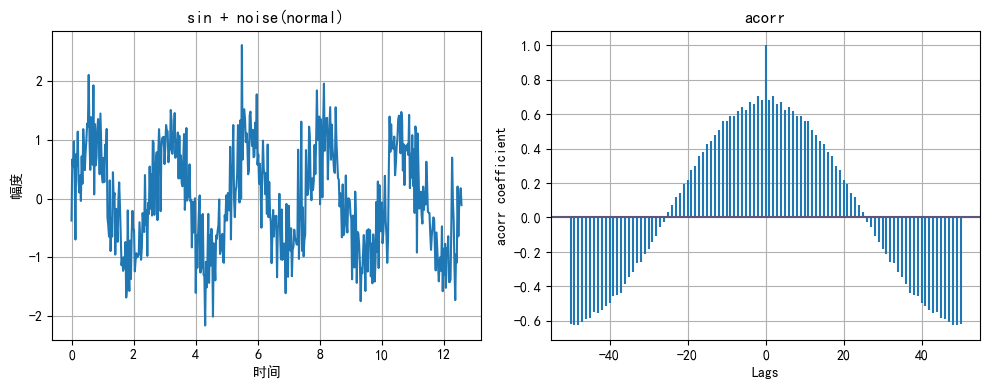

In [47]:
import matplotlib.pyplot as plt
import numpy as np


# 1. 生成一个带有噪声的正弦波时间序列
np.random.seed(2025101714) # 保证每次运行结果一致（默认采用当前时间作为随机种子）
t = np.linspace(0, 4*np.pi, 500)  # 生成2个圆周的时间序列
# 基础正弦波 + 随机噪声
y = np.sin(t) + 0.5 * np.random.randn(len(t))  # 使用正态分布产生噪声

# 2. 绘制原始数据
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.plot(t, x)
plt.title('sin + noise(normal)')
plt.xlabel('时间')
plt.ylabel('幅度')
plt.grid(True)

# 3. 绘制自相关图
plt.subplot(122)
# 使用 acorr 函数，设置 maxlags=50 以查看前50个滞后
lags, c, line, b = plt.acorr(x, maxlags=50)  # 返回四个对象
print(lags)
print(c)
plt.title('acorr')
plt.xlabel('Lags')
plt.ylabel('acorr coefficient')
plt.grid(True)

# 在滞后0处，自相关系数总是1，我们画一条参考线
plt.axhline(y=0, color='red', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

- 代码说明：
    - 上面代码中，带噪声的数据可视化比较容易理解，自相关系数理解起来比较困难，我们从下面技术角度理解：
        - 自相关主要用于检测数据中是否存在趋势。任何时间数据序列与自身的相关性总是为1。
        - 自相关的计算方法与过程：假设时间数据序列是$(x_1, x_2, \dots, x_n)$
            - 第一步：计算均值$m = (x_1 + x_2 + \dots + x_n) / n = \dfrac{1}{n}\sum_{i=1}^{n} \limits x_i$
            - 第二步：计算自协方差：$c_k = \dfrac{1}{n} \sum _{t=k+1} ^{n} \limits (x_t - m)(x_{t-k} - m)$，k阶滞后就是错开k个位置计算自协方差。
            - 第三步：计算自相关系数：$r_k = \dfrac{c_k}{c_0}$
        - 提示：
            - 上面的k就是滞后阶数。
            - k=0就是数据序列与自身的相关系数计算，$r_0 = 1$，自相关系数在滞后阶数为0的情况下总是为1。而且自相关系数满足如下规律：
                - $c_0 = 1$
                - $ -1 \le c_k \le 1$
                - $c_k = c_{-k}$：对称。
    - 我们具备上面的自相关系数的计算知识后，我们再看acorr函数绘制的图形，就相对理解acorr函数的作用（尤其是数据分析可视化中的作用）：
        - 代码中绘制的图形就是滞后`[-50，50]`之间的自相关系数，滞后越短，自相关性越大，相关性越强。
        - 检测数据中是否存在趋势与季节性，通过过去的值对预测未来值非常有帮助。
        - 代码中的图形说明，当前数据对大约滞后5-10个时间序列的数据预测比较有效（专业术语：相关系数**统计显著**）。
        - 季节性：在固定的周期滞后处（如滞后12、24对于月度数据，我们例子使用的是圆周周期）出现显著的相关峰。

- detrend参数使用例子

- detrend参数提供一个函数过程去趋势，使用者可以在观察数据具有明显趋势时，采用去趋势处理，去趋势方法常见的有如下几种：
    - detrend_none：不去趋势。
    - detrend_mean：去均值。
    - detrend_linear：线性去趋势。

时间序列统计:
均值: 1.949
标准差: 2.045


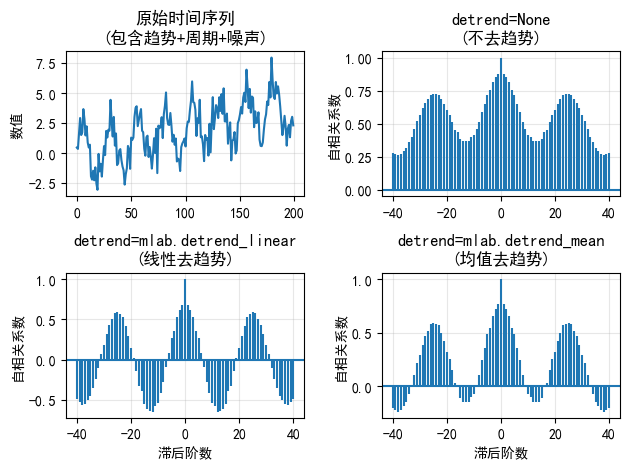

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.mlab as mlab

plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体

# 创建具有趋势和周期性的时间序列
np.random.seed(42)
n_points = 200
time = np.arange(n_points)  # 生成200个均匀的样本点。

# 创建复杂的时间序列：趋势 + 周期 + 噪声
trend = 0.02 * time                           # 趋势
seasonal = 2 * np.sin(2 * np.pi * time / 25)  # 季节性
noise = np.random.normal(0, 1, n_points)      # 噪声
data = trend + seasonal + noise               # 最终生成的样本数据

print("时间序列统计:")
print(f"均值: {np.mean(data):.3f}")
print(f"标准差: {np.std(data):.3f}")



# 比较不同的去趋势方法
# 原始数据
plt.subplot(221)
plt.plot(data)
plt.title('原始时间序列\n(包含趋势+周期+噪声)')
plt.ylabel('数值')
plt.grid(True, alpha=0.3)

# 无去趋势
plt.subplot(222)
plt.acorr(data, detrend=mlab.detrend_none, maxlags=40)
plt.title('detrend=None\n(不去趋势)')
plt.ylabel('自相关系数')
plt.grid(True, alpha=0.3)

# 线性去趋势
plt.subplot(223)
plt.acorr(data, detrend=mlab.detrend_linear, maxlags=40)
plt.title('detrend=mlab.detrend_linear\n(线性去趋势)')
plt.xlabel('滞后阶数')
plt.ylabel('自相关系数')
plt.grid(True, alpha=0.3)

# 均值去趋势
plt.subplot(224)
plt.acorr(data, detrend=mlab.detrend_mean, maxlags=40)
plt.title('detrend=mlab.detrend_mean\n(均值去趋势)')
plt.xlabel('滞后阶数')
plt.ylabel('自相关系数')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



- 代码说明：
    - 代码中只是使用了matplotlib.mlab模块提供的三个去趋势函数。其实去趋势还有很多算法，使用者可以自己实现去趋势处理。下面我们列出常见去趋势方法：
        - 平均去趋势：
            - 趋势估计(就是计算平均数)：$\hat{\mu} = \frac{1}{n}\sum_{t=1}^n y_t$
            - 去除趋势计算：$\hat{\epsilon}_t = y_t - \hat{\mu}$
        - 线性去趋势：
            - 假设数据序列满足线性规律：$y_t = \alpha t + \beta + \epsilon_t$
            - 使用均方误差作为损失函数，估计系数$\hat{\alpha}$与$\hat{\beta}$：$\min_{\alpha,\beta} \sum_{t=1}^n \limits (y_t - \alpha t - \beta)^2$
            - 去趋势计算公式（得到最后的数据就是去趋势数据）：$\hat{\epsilon}_t = y_t - \hat{\alpha} - \hat{\beta}t$
        - 多项式去趋势：
        - 移动平均去趋势：
        - LOESS/LOWESS去趋势：
        - Hodrick-Prescott (HP) 滤波去趋势：
        - 差分去趋势：
        - 小波去趋势：
        - 经验模态分解去趋势：

- 定制实现去趋势函数例子

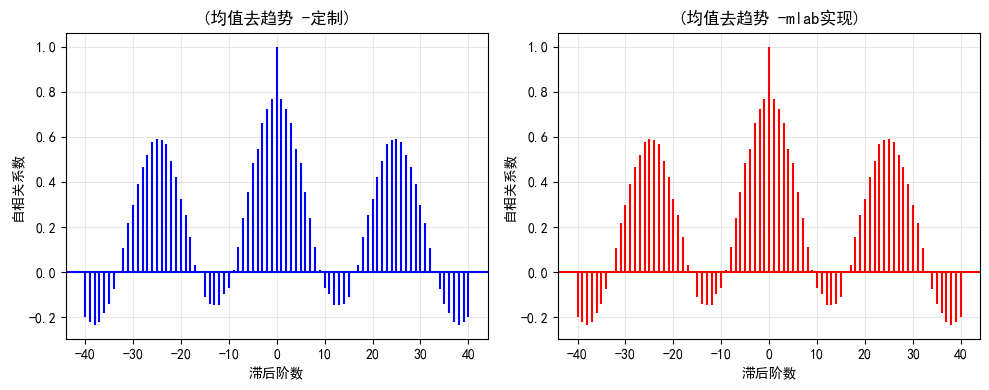

In [60]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.mlab as mlab

plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体

# 创建具有趋势和周期性的时间序列
np.random.seed(42)
n_points = 200
time = np.arange(n_points)  # 生成200个均匀的样本点。

# 创建复杂的时间序列：趋势 + 周期 + 噪声
trend = 0.02 * time                           # 趋势
seasonal = 2 * np.sin(2 * np.pi * time / 25)  # 季节性
noise = np.random.normal(0, 1, n_points)      # 噪声
data = trend + seasonal + noise               # 最终生成的样本数据

plt.figure(figsize=(10, 4))
# -------------比较不同的去趋势方法----------
def detrend_custom(x):
    m = np.mean(x)
    return x - m

# 均值去趋势 - 定制
plt.subplot(121)
plt.acorr(data, detrend=detrend_custom, maxlags=40, color='blue')
plt.title('(均值去趋势 -定制)')
plt.xlabel('滞后阶数')
plt.ylabel('自相关系数')
plt.grid(True, alpha=0.3)

# 均值去趋势 - 官方
plt.subplot(122)
plt.acorr(data, detrend=mlab.detrend_mean, maxlags=40, color='red')
plt.title('(均值去趋势 -mlab实现)')
plt.xlabel('滞后阶数')
plt.ylabel('自相关系数')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



- 代码说明：
    - 代码中实现了均值去趋势函数`detrend_custom`，函数的参数其实就是序列数据，输出的是去趋势后的数据。
    - detrend_custom的实现方法很简单，先计算平均数m，然后使用x-m进行去趋势计算。

- usevlines参数使用例子
    - 这个参数为False的时候，还有相关的参数：linestyle与marker。其他参数可以参考plot与Line2D的属性。

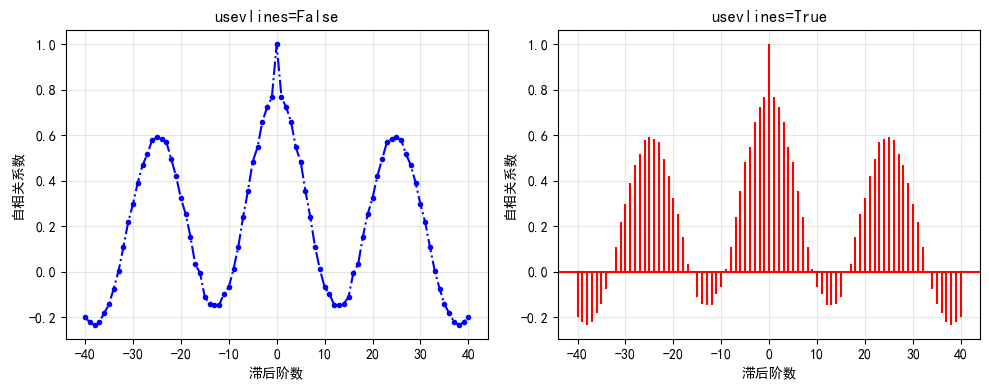

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.mlab as mlab

plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体

# 创建具有趋势和周期性的时间序列
np.random.seed(42)
n_points = 200
time = np.arange(n_points)  # 生成200个均匀的样本点。

# 创建复杂的时间序列：趋势 + 周期 + 噪声
trend = 0.02 * time                           # 趋势
seasonal = 2 * np.sin(2 * np.pi * time / 25)  # 季节性
noise = np.random.normal(0, 1, n_points)      # 噪声
data = trend + seasonal + noise               # 最终生成的样本数据

plt.figure(figsize=(10, 4))
# -------------比较不同的去趋势方法----------
def detrend_custom(x):
    m = np.mean(x)
    return x - m

# 均值去趋势 - 定制
plt.subplot(121)
plt.acorr(data, detrend=detrend_custom, maxlags=40, usevlines=False, color='blue', linestyle="-.", marker=".")
plt.title('usevlines=False')
plt.xlabel('滞后阶数')
plt.ylabel('自相关系数')
plt.grid(True, alpha=0.3)

# 均值去趋势 - 官方
plt.subplot(122)
plt.acorr(data, detrend=mlab.detrend_mean, maxlags=40, usevlines=True, color='red')
plt.title('usevlines=True')
plt.xlabel('滞后阶数')
plt.ylabel('自相关系数')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



- 代码说明：
    - usevlines参数默认是True，可以通过设置usevlines=False，使用linestyle与marker等相关属性定制化可视化输出。

- 使用cohere函数可视化两个信号（数据序列）的相干性
    - cohere 函数用于计算两个信号之间的相干性，也称为幅度平方相干性。相干性衡量的是两个信号在频域上的相关性，取值范围在0到1之间。

- cohere函数的原型定义与参数说明：
    - 关于这个函数的理解，可以补充看函数说明后面的相关知识介绍。

```python
matplotlib.pyplot.cohere(
    x, y,  # 两个数据序列（表示信号）
    *, 
    NFFT=256, # 用于计算傅里叶变换的每个数据块的数据点数量、建议使用2的次方数，数据太小没有统计效果
    Fs=2,   # 采样频率（单位为周期/时间单位）
    Fc=0,   # x的中心频率，在绘制时指定中心频率偏移，体现频率范围
    detrend=<function detrend_none>,   # 在进行FFT(傅里叶变换)之前的去趋势处理（去均值或者线性性）
    window=<function window_hanning>, # 用对数据段进行窗函数处理（主要减少频率泄露）
    noverlap=0,   # 数据分块之间的重叠点数量
    pad_to=None,  # 执行FFT时填充数据段的点数。默认值为None，它将pad_t设置为等于NFFT
    sides='default', # 设置频谱返回的边带，取值{'default', 'onesided', 'twosided'},取值default对于真实数据是单侧的，对于复杂数据是双侧的。
    scale_by_freq=None,  # 是否应按缩放频率缩放得到的密度值，参数类型是逻辑值，默认是True
    data=None, 
    **kwargs)
```
函数返回：Cxy互相关系数向量，freqsCxy中每个原色的对应频率。

- cohere函数涉及的专业领域比较强，需要具有一定的专业知识，同时也非常有用，尽管学习有难度，但可以通过本内容的学习，提升相关的专业知识。

- 数学概念 - **互相关函数**
    - **互相关函数**描述了两个不同信号在不同时间偏移量下的相似性。对于两个能量有限的信号$x(t)$和$y(t)$，相关性函数定义如下：\ast
        - 连续形式：$R_{xy}(\tau) = \int _{-\infty} ^ {\infty} x(t) . y^{\ast}(t-\tau)\mathrm{d}t $
        - 离散形式：$R_{xy}[m]) = \sum _{n=-\infty} ^ {\infty} \limits x[n] . y^{\ast}[n-m]$
    - 其中符号说明：
        - $\tau$和$m$是时间滞后量（延迟）
        - $y^{\ast}$是$y$的复共轭，对实数来讲就是$y$本身。
    - **互相关函数**的物理意义：
        - 用麦克风阵列测声源位置。声音到达不同麦克风有时间差。计算两个麦克风信号的互相关函数，峰值出现的位置就对应了这个时间差，从而可以定位声源（雷达类似）。

- 数学概念 - 互功率谱密度
    - **互功率谱密度**就是互相关函数的傅里叶变换。根据 Wiener-Khinchin 定理（这个定理说明了功率谱是自相关函数的傅里叶变换）
        - $P_{xy}(f) = \mathcal{F}\{R_{xy}(\tau)\} = \int \limits _{-\infty}^{\infty} R_{xy}(\tau)e^{-j2\pi f \tau} \mathrm{d} \tau$
    - 为了便于计算，通常**互功率谱密度**定义为两个信号的傅里叶变换的复共轭乘积的期望值。
        - $P_{xy}(f) \approx \mathbb{E}[X(f) . Y^{\ast}(f)]$
        - $X(f)$是信号$x(t)$的傅里叶变换。$Y^{\ast}(f)$是信号$y(t)$的傅里叶变换复共轭。
        - $\mathbb{E}$表示求期望值。

 - 数学概念 - 相关性
     - 相干性(相干性函数)用于衡量两个信号在频域上的线性相关性
         - $C_{xy}(f) = \dfrac{|P_{xy}(f)|^2}{P_{xx}(f) . P_{yy}(f)}$

- cohere的实现过程（计算过程）
    - 分段：将长信号$x[n]$和$y[n]$,分成K段较短的、可能重叠的数据段。
    - 加窗：对每一段数据乘以一个窗函数（如汉宁窗），以减少频谱泄漏。
    - FFT：对每一段加窗后的数据$x_i [n]$和$y_i [n]$分别进行傅里叶变换，得到$X_i (f)$和$Y_i (f)$。
    - 计算互谱：对每一段，计算$X_i (f) . Y^{\ast}(f)$。
    - 频谱估计：将所有K段的计算结果进行平均，得到最终的互功率谱密度估计。
    - 平均处理：对所有段的估计结果进行平均。
    - 相干性计算：根据公式计算最终的相干性

- cohere函数的应用基本例子：

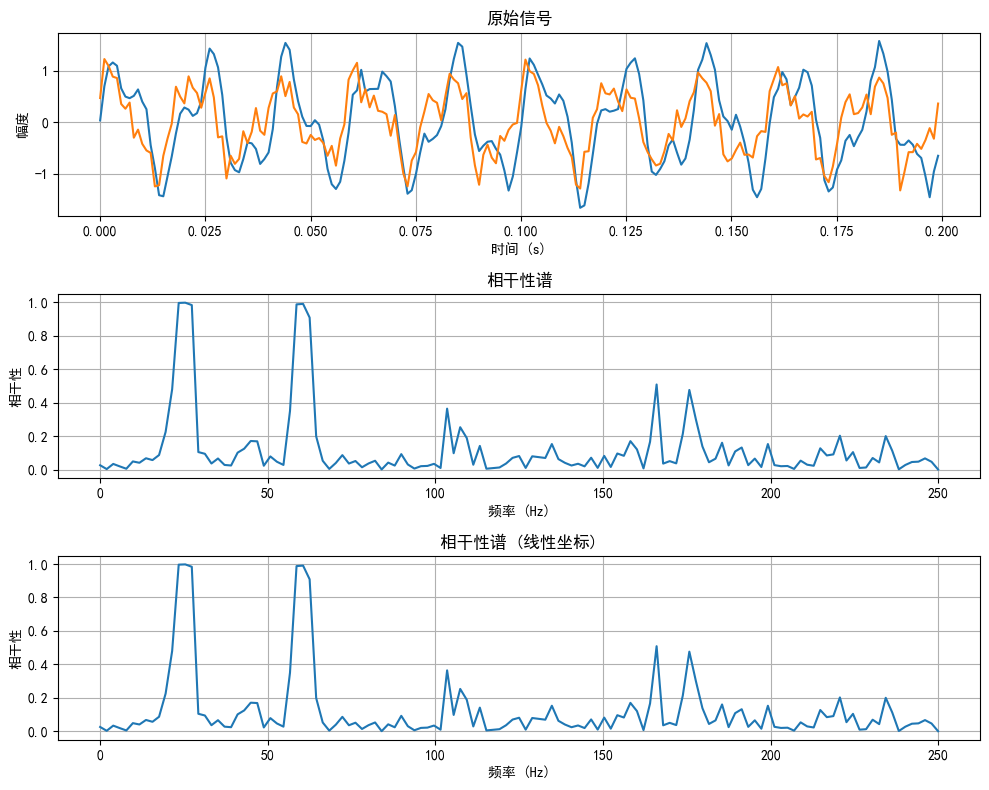

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import mlab
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文无法显示的问题
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 1. 生成测试信号 -------------------------------
fs = 1000  # 采样频率（决定数据点数量）
t = np.linspace(0, 2, 2*fs)  # 2秒时间向量，一共2000个数据点

# 信号1：包含50Hz和120Hz成分
x = (np.sin(2*np.pi*50*t) +       # 50赫兹
     0.5*np.sin(2*np.pi*120*t) +  # 120赫兹，振幅减半
     0.1*np.random.randn(len(t))) # 噪声（系数0.1控制噪声程度） - 误差

# 信号2：与x部分相关，包含相位差和噪声
y = (0.8*np.sin(2*np.pi*50*t + np.pi/4) +  # 50赫兹 +45°相位
     0.3*np.sin(2*np.pi*120*t) + 
     0.2*np.random.randn(len(t)) +
     0.1*np.sin(2*np.pi*200*t))  # 额外的不相关频率成分（200赫兹）

# 2. 绘制两个信号的互相干系数

plt.figure(figsize=(10, 8))

# 绘制原始信号
plt.subplot(3, 1, 1)
plt.plot(t[:200], x[:200])
plt.plot(t[:200], y[:200])
plt.xlabel('时间 (s)')
plt.ylabel('幅度')
plt.title('原始信号')
plt.grid(True)

# 绘制相干性
plt.subplot(3, 1, 2)
Cxy, f = plt.cohere(x, y, Fs=500, NFFT=256, window=mlab.window_hanning, noverlap=128)
plt.xlabel('频率 (Hz)')
plt.ylabel('相干性')
plt.title('相干性谱')
plt.grid(True)

# 使用线性坐标绘制
plt.subplot(3, 1, 3)
plt.plot(f, Cxy)
plt.xlabel('频率 (Hz)')
plt.ylabel('相干性')
plt.title('相干性谱 (线性坐标)')
plt.grid(True)

plt.tight_layout()
plt.show()


- 代码说明
    - 找个代码中比较难以理解的还是是cohere函数中的概念，其中我们生成的两个信号，其中信号的频率是一个理解难点。
    - `np.sin(2*np.pi*50*t)`中50表示频率，单位是Hz(赫兹)，表示每个时间点，采样都是在信号的`2*np.pi*50`位置，对于一个周期`2*np.pi`来说，每次采样就是就是50个周期，这就是频率。
    - 傅里叶变换可以把一个信号分解成多个频率信号的和。然后我们就可以对每个频率的信号进行相关性分析。比如图表中，我们初步可以判断出两个信号在频率为25与60的时候，相干性最强。
    - 如果两个信号在绝大部分频率上相干性都很强（数值接近1），说明两个信号相干性强。信号与同一个新的想干性咋所有频率上都是1.

- 使用xcorr函数绘制两个数据序列之间的**互相关性**。

- xcorr函数原型定义与参数说明：

```python
matplotlib.pyplot.xcorr(
    x,   # 数据序列，类型是长度为n的数组（向量）。- 可以看着信号1
    y,   # 数据序列，类型是长度为n的数组（向量）。- 可以看着信号2
    *, 
    normed=True, # 对输入向量做标准化（单位化）
    detrend=<function detrend_none>,  # 对信号进行去趋势处理。
    usevlines=True,  # 使用处置竖线，默认值是True。如果为False在采用plot绘制。
    maxlags=10,  # 最大滞后个数
    data=None,   # 结构化数据。
    **kwargs)
```

函数返回：lags滞后数组（长度2*maxlags+1），c相关性向量， line返回LineCollection()或者Line2D

- 互相关函数xcorr与acorr从数学原理是类似的。
    - acorr是xcorr特例，acorr都是xcorr函数在x=y的情况的特例。

- 上面我们已经简单介绍了**互相关**的概念。
    - 互相关是一种衡量两个信号在不同时间偏移（滞后） 下相似程度的度量。

- xcorr函数的计算过程如下：
    - 第一步预处理：去趋势
    - 第二步计算原始相关系数。
    - 第三步滞后向量的生成
    - 第四步规范化（normed）

- 下面我们使用两个离散的数据序列来理解上面的计算过程。
    - 假设$x=[2, 3, 1]$，$y=[1, 2, 2]$
    - 第一步预处理：去趋势，我们不去趋势，采用原始数据，如果要采用均值去趋势，具体算法见上面。
    - 第二步计算原始相关系数：
        - 滞后-2：$x[2] \ast y[0] = 1 \ast 1$
        - 滞后-1：$x[1] \ast y[0] + x[2] \ast y[1] = 3 \ast 1 + 1 \ast 2 = 5$
        - 滞后 0：$x[0] \ast y[0] + x[1] \ast y[1] + x[2] \ast y[2] = 2 \ast 1 + 3 \ast 2 + 1 \ast 2 = 10$
        - 滞后 1：$x[0] \ast y[1] + x[1] \ast y[2] = 2 \ast 2 + 3 \ast 2 = 10$
        - 滞后 2：$x[0] \ast y[2] = 2 \ast 2 = 4$

- xcorr函数使用的例子：

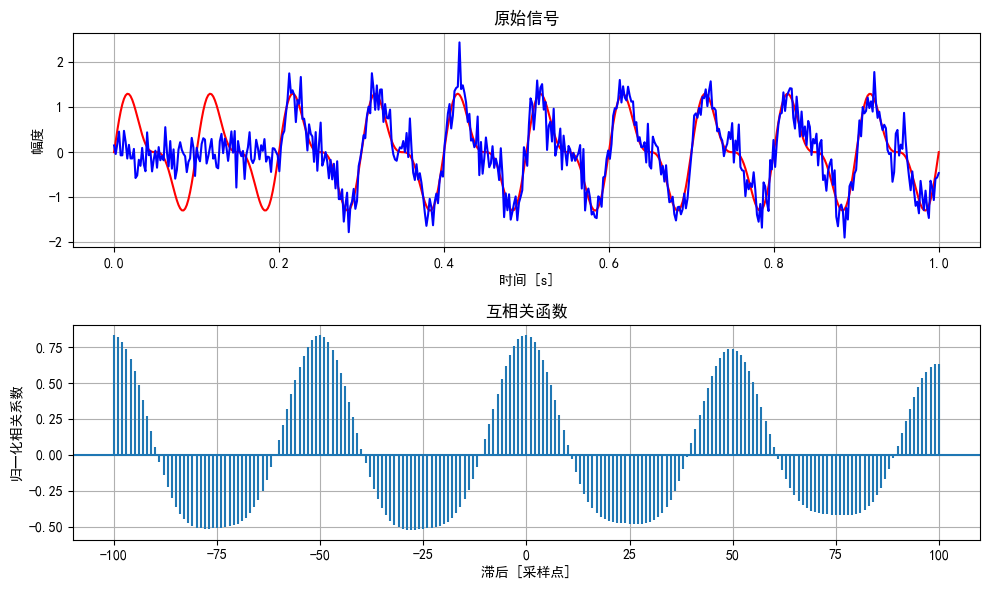

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import mlab

# 设置随机种子以便结果可重现
np.random.seed(42)

# 创建示例数据
t = np.linspace(0, 1, 500)
# 原始信号 x：包含多个频率成分
x = np.sin(2 * np.pi * 10 * t) + 0.5 * np.sin(2 * np.pi * 20 * t)
# 信号 y：x 的延迟版本，并添加一些噪声
delay_samples = 100  # 延迟100个采样点
y = np.zeros_like(x)
y[delay_samples:] = x[:-delay_samples]
y += 0.3 * np.random.randn(len(y))  # 添加噪声

# 绘制原始信号
plt.figure(figsize=(10, 6))

plt.subplot(211)
plt.plot(t, x, color="r")
plt.plot(t, y, color="b")
plt.xlabel('时间 [s]')
plt.ylabel('幅度')

plt.title('原始信号')
plt.grid(True)

# 计算并绘制互相关
plt.subplot(212)
# 计算互相关，归一化并去均值
corr = plt.xcorr(x, y, normed=True, detrend=mlab.detrend_mean, maxlags=100)
plt.grid(True)
plt.title('互相关函数')
plt.xlabel('滞后 [采样点]')
plt.ylabel('归一化相关系数')

plt.tight_layout()
plt.show()

- 代码说明：
    - maxlags参数只能是None或者大于0的数。
    - 从图表中可以看出，滞后-50，两个信号是最相关的，因为第二个信号就是第一个信号延迟100个采样点，并且添加噪声得到的。滞后为正的情况相关性略差，因为前面有100个样本是纯噪声。

### (2) 频谱分析绘制

- 主要的频谱分析函数有：
    - angle_spectrum函数：绘制信号的角度谱（包裹相位谱）的函数。它显示了信号在频域中的相位信息。
    - csd函数：计算和绘制互功率谱密度的函数
    - magnitude_spectrum函数：计算和绘制信号的幅度谱函数
    - phase_spectrum函数：计算和绘制信号的相位谱（展开角谱）
    - psd函数：计算和绘制信号功率谱密度的函数
    - specgram函数：计算并绘制信号的频谱图

- 因为这些函数主要用于信号分析，其专业性太强，我们这里不一一展开。

## 3.4. 统计图

- 在pyplot中提供如下统计图绘制函数
    - ecdf函数：负责绘制经验累积分布的函数。在数据分析和统计可视化中，ECDF常用于比较数据分布、检验分布假设等。
    - boxplot函数：负责绘制箱线图的函数。它可以直观地展示数据的分布情况，包括中位数、四分位数、异常值等统计信息。
    - violinplot函数：负责绘制小提琴图的函数，它结合了箱形图和核密度估计的特点，能够展示数据的分布形状及其概率密度。
- 这部分内容需要具有概率与数理统计的知识。

### (1) 经验累积分布图绘制-ecdf

- 数学概念 - 经验累积分布函数
    - 经验累积分布函数 是根据数据样本本身来估计总体累积分布函数的一种方法。经验累积分布可以用来判断：对于给定的数值x，数据集中有多大比例的观测值小于或等于x值？

- 假设有数据：$X = [x_1, x_2, \dots, x_n]$，ecdf的计算方法如下：
    - 对数据集$X$排序。
    - 计算ecdf值 = $\dfrac{i}{n}$，其中$i$是排序后的第$i$个数据点位置。我们可以表述为下面公式：
        - edcf(x) = $\dfrac{小于等于x的数据样本}{n}$

- ecdf函数负责绘制经验累积分布图，其数据可视化中的作用是：
    - 展示数据的完整分布信息。
    - 比较多个数据集的分布。
    - 检验数据是否符合特定分布。
    - 提供无偏的分布视图，避免直方图分箱带来的偏差。

- ecdf函数的原型定义与参数说明：

```python
matplotlib.pyplot.ecdf(
    x,     # 需要绘制的数据，参数类型是一维数组。
    weights=None, # 对x进行加权处理，与x一样形状的权重数据
    *, 
    complementary=False,  # 参数类型是bool值，用来确定是否绘制互补图形 （1 - ecdf返回值），默认值是False
    orientation='vertical',  # 参数用来指定绘制的分布按照x轴，或者y还是绘制，参数取值{"vertical", "horizontal"}，horizontal表示按照水平方向绘制，vertical表示按照垂直方向绘制。
    compress=False, 
    data=None, 
    **kwargs)  # 来自Line2D对象的属性。
```

- 使用ecdf函数绘制经验累积分布的例子：

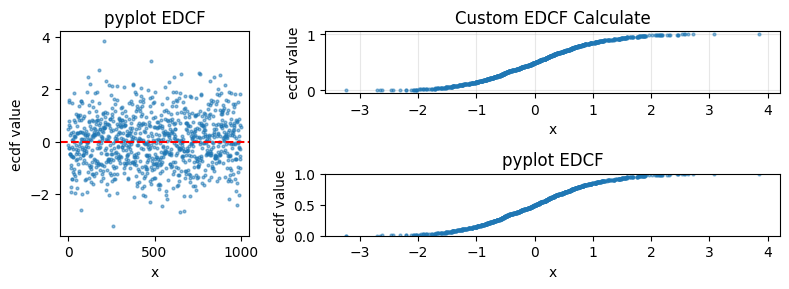

In [18]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# 生成示例数据
np.random.seed(42)
data = np.random.normal(0, 1, 1000)

plt.figure(figsize=(8, 3))
# ----------------- 原始数据 -----------------
plt.subplot2grid((2, 3), (0, 0), rowspan=2)
plt.plot(range(0, 1000), data, marker='.', markersize=4, linestyle='', alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', label='Mean(μ=0)') 
plt.xlabel('x')
plt.ylabel('ecdf value')
plt.title('pyplot EDCF')

# ------------------定制计算经验累积分布----------
# 计算ECDF
def ecdf(data):
    """计算ECDF"""
    x = np.sort(data)
    y = np.arange(1, len(data) + 1) / len(data)
    return x, y
# 计算数据的ECDF
x, y = ecdf(data)
# 绘制ECDF
plt.subplot2grid((2, 3), (0, 1), colspan=2)
plt.plot(x, y, marker='.', markersize=4, linestyle='', alpha=0.5)
plt.xlabel('x')
plt.ylabel('ecdf value')
plt.title('Custom EDCF Calculate')
plt.grid(True, alpha=0.3)

# ------------------ecdf函数计算经验累积分布----------
plt.subplot2grid((2, 3), (1, 1), colspan=2)
plt.ecdf(x, marker='.', markersize=4, linestyle='', alpha=0.5)
plt.xlabel('x')
plt.ylabel('ecdf value')
plt.title('pyplot EDCF')



plt.tight_layout()


- 代码说明：
    - 在代码中，我们绘制了使用正态分布生成的数据样本点，这个正态分布的均值$\mu = 0$，方差$\delta = 1$(图绘制在左边)
    - 右边上面的是我们自己计算的ecdf值，右边下面是pyplot.ecdf函数绘制的效果，我们通过`**kwargs`设置了绘制样式，`linestyle=""`表示不绘制线段，只绘制marker，这个效果与scatter函数的效果一样。
    - 我们通过右边的图，可以看出经验累积函数计算的值可以当成概率，实际ecdf是通过统计数据的百分比，实际得到接近理论概率的近似概率，换句话说，我们最终绘制的是接近理论正态分布函数的**经验正态分布概率**。
    - 我们可以得到结论：通过经验累积分布可以知道样本点的分布规律（比如我们左边数据看不出分布规律，但是右边可以看出具有正态分布规律）

- 比较ecdf的经验累积分布与正态分布累积函数的分布图表例子：

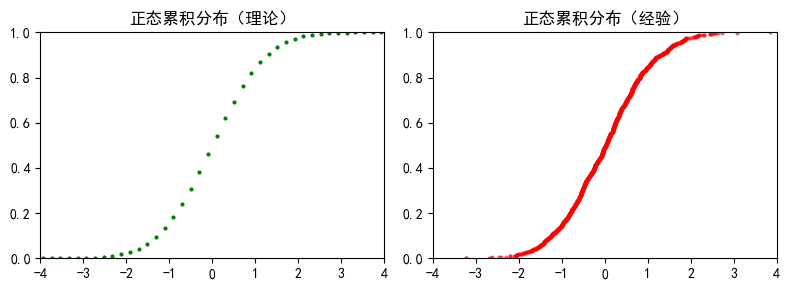

In [29]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate as integrate
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文无法显示的问题
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

plt.figure(figsize=(8, 3))

# 我们自己定义的正态分布函数
def  normal(t, m, s):
    # 系数-方差
    sigma=s
    # 系数-均值
    mu=m
    # 正态分布常数系数
    coefficient = 1.0 / ( np.sqrt( 2 * np.pi) * sigma )
    # 正态分布指数
    exponent = -(t-mu)**2/(2*sigma**2)
    re=coefficient * np.exp( exponent )
    return re

# 利用SciPy的quad做积分运算
def cumulative(x):
    re=integrate.quad(     
        normal,         # 积分函数
        -np.inf,         # 积分下限
        x,              # 积分上限
        args=(0.0, 1.0)   # 传递给函数的参数（除第一个参数外，按照顺序来）
    )
    return re[0]     #第一个是积分，第二个是误差上限

plt.subplot(121)
plt.xlim(-4, 4)
plt.ylim(0, 1)
x_n=np.linspace( -10 ,10, 100,  dtype=np.float32 )
y_n=[cumulative(x) for  x in x_n ]
plt.plot(x_n, y_n,color='green', marker='.', markersize=4, linestyle='')
plt.title("正态累积分布（理论）")

# 生成示例数据
plt.subplot(122)
plt.xlim(-4, 4)
plt.ylim(0, 1)
np.random.seed(42)
data = np.random.normal(0, 1, 1000)
plt.ecdf(x, complementary=False, marker='.', markersize=4, linestyle='', color="red", alpha=0.5)
plt.title("正态累积分布（经验）")

plt.tight_layout()


- ecdf函数中参数的使用例子：
    - weights：权重，这个在某些场景的调查数据可能需要根据一些特殊情况，进行加权计算。
    - complementary：经验累积分布的补分布。
    - compress：对相同的数据进行分组，可以减少数据量

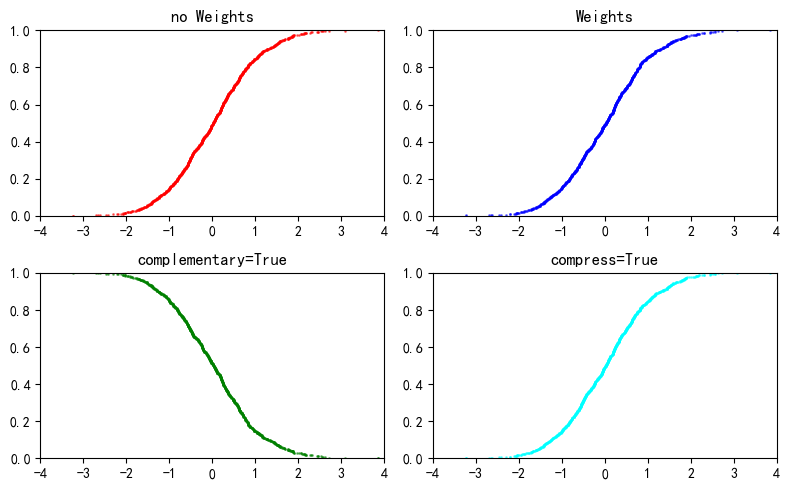

In [46]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate as integrate
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文无法显示的问题
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

plt.figure(figsize=(8, 5))

# 生成示例数据
np.random.seed(42)
data = np.random.normal(0, 1, 1000)
o_weights = np.array([0.1, 0.2, 0.3, 0.7, 0.8, 0.9, 1.0])
weights = np.random.choice(o_weights, size=1000, replace=True)

plt.subplot(221)
plt.xlim(-4, 4)
plt.ylim(0, 1)
plt.ecdf(x, marker='.', markersize=2, linestyle='', color="red", alpha=0.5)
plt.title("no Weights")

plt.subplot(222)
plt.xlim(-4, 4)
plt.ylim(0, 1)
plt.ecdf(x, weights=weights, marker='.', markersize=2, linestyle='', color="blue", alpha=0.5)
plt.title("Weights")

plt.subplot(223)
plt.xlim(-4, 4)
plt.ylim(0, 1)
plt.ecdf(x, weights=weights, complementary=True, marker='.', markersize=2, linestyle='', color="green", alpha=0.5)
plt.title("complementary=True")

plt.subplot(224)
plt.xlim(-4, 4)
plt.ylim(0, 1)
plt.ecdf(x, compress=True, marker='.', markersize=2, linestyle='', color="cyan", alpha=0.5)
plt.title("compress=True")

plt.tight_layout()


- 代码说明：
    - 参数在绘制效果上，体验不是特别明显，可以仔细观察发现细微的差异，可以调整不同参数值反复体验。

### (2) 箱线图绘制-boxplot

- boxplot函数是matplotlib.pyplot中用于绘制箱线图的函数，通过中位数、四分位数、异常值等统计信息直观地展示数据的分布情况。

- boxplot函数的原型定义：

```python
matplotlib.pyplot.boxplot(
    x, 
    *, 
    notch=None,  # 使用缺口显示中位数的置信区域。
    sym=None, # 设置异常点样式。
    vert=None,  # 该参数已经不推荐使用，在3.13版本已经不在支持。使用orientation替代。
    orientation='vertical', # vert参数的替代参数。
    whis=None,  # 计算须线上下限的系数，默认是1.5
    positions=None,   # 设置每个箱子的x轴坐标位置
    widths=None,    # 设置每个箱子的宽度
    patch_artist=None,  # 设置箱体是线条构成的空心（不能填充颜色），还是Patch构成的实心（可填充颜色）
    bootstrap=None,   # 计算中位数的置信区域使用的采样次数（有放回采样）
    usermedians=None,  # 设置需要显示的中位数，不设置就自动计算
    conf_intervals=None,   # 设置指定的置信区域，为None就自动计算
    meanline=None,   # 是否绘制均值线
    showmeans=None,  # 是否绘制均值
    showcaps=None,   # 是否绘制须线帽盖
    showbox=None,    # 是否绘制箱体
    showfliers=None,  # 是否绘制异常点
    boxprops=None,    # 设置箱体属性
    tick_labels=None,  # 设置每个箱子的x轴刻度标签
    flierprops=None,  # 设置异常点属性
    medianprops=None,  # 设置中位数属性
    meanprops=None, # 设置均值属性
    capprops=None,  # 这是须线帽盖属性
    whiskerprops=None, # 设置须线属性
    manage_ticks=True,  # 是否根据箱子的数据显示刻度。
    autorange=False, # 设置箱子在x轴的刻度计算方法
    zorder=None,  # 每个箱子的绘制顺序
    capwidths=None, # 须线帽盖线宽度。
    label=None, 
    data=None)
```

- boxplot函数的返回值是一个字典，字典有如下关键字代表的数据：
    - boxes: 构成箱体的Line2D对象数组
    - medians: 构成中位线的Line2D对象数组
    - whiskers: 构成须线的Line2D对象数组
    - caps: 须线末端的水平线的Line2D对象数组
    - fliers: 代表须线外的数据点对象的Line2D对象数组
    - means: 代表平均值的点或线的Line2D对象
- 可以通过这些对象，设置这些对象显示的外观属性。 

- 箱线图的数据参数说明：
    - 通过参数x设置箱线图需要绘制的数据。
    - 参数类型是向量数组或者序列（不规则），也可以是二维数组（规则）。如果是向量序列，则会为序列中每个箱线图。如果是二维数组，则会为每个列绘制箱线图。

- boxplot函数x参数的使用例子：

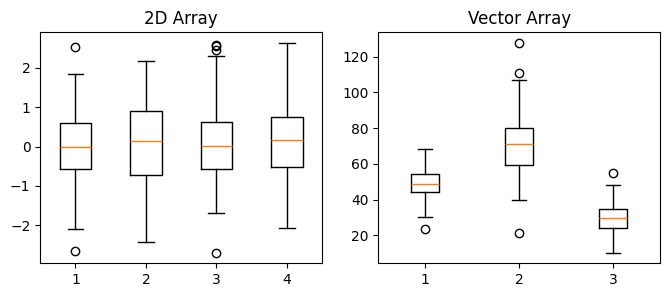

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 创建示例数据（）
data1 = np.random.normal(0, 1, size=(100, 4))

np.random.seed(42)
d1 = np.random.normal(50, 10, 100)
d2 = np.random.normal(70, 15, 200)
d3 = np.random.normal(30, 8, 300)
data2 = [d1, d2, d3]


# 绘制基本箱线图
plt.figure(figsize=(8, 3))

plt.subplot(121)
plt.boxplot(data1)
plt.title('2D Array')

plt.subplot(122)
plt.boxplot(data2)
plt.title('Vector Array')

plt.show()

- 代码说明
    - `data1 = np.random.normal(0, 1, size=(100, 4))`生成一个2维数组，每一列一个箱线图。 因为数据组是(100,4)，所有第一个图表绘制了4个箱线图。
    - `data2 = [d1, d2, d3]`生成了一个向量数组，一共三个向量，一个向量绘制一个箱线图，所以绘制了3个箱线图。

- 认识箱线图
    - 箱线图，又称盒须图、箱形图，由美国著名统计学家约翰·图基在1977年提出。它的核心思想是用几个关键的分位数来统计一组数据，从而以一种标准化的方式直观展示数据的，它的主要优点是不受极端值影响，能够稳健地展示数据分布，并且非常节省空间，便于在有限区域内并排比较多个数据集：
        - **中心位置**：中位数所在的位置代表了数据的中心。
        - **离散程度**：箱体的高度和须线的长度反映了数据的波动情况。
        - **偏态**：中位数在箱体中的位置，以及上下须线的长度对比，可以指示数据分布的偏斜方向。
        - **潜在异常值**：能够清晰地识别出远离主体数据的极端值。
    - 一个标准的箱线图由以下几个关键组件构成，每个部件都对应着数据的一个特定分位数或统计量，箱线图的组件结构：
        - **箱体（Box）**：
        - **上须线（Upper Whisker）**：
            - 须线的实际**顶端**是原始数据中小于或等于此上限的最大值。它代表了“正常”数据的理论上限。
        - **下须线（Lower Whisker）**：
            - 须线的实际*底端**是原始数据中大于或等于此下限的最小值。它代表了“正常”数据的理论下限。
        - **异常值（Outliers）**：

- **箱体(Box)**
    - 箱体代表的是数据中的50%的数据。
        - **下边界**（25%的数据边界）：对应第25百分位数(简称Q1，第一四分位，**下四分位**)。
        - **箱体内的线**（50%的数据分界线）：对应第50百分位数（简称Q2，第二四分位，**中位数**）。这条线的位置可以反映数据的偏态。如果线在箱体中央，分布大致对称；如果线靠近Q1，则数据右偏（正偏）；如果线靠近Q3，则数据左偏（负偏）。
        - **上边界**（75%的数据边界）：对应第75百分位数（简称Q3，第三四分位，**下四分位**）。
        - **箱体高度**：表示**四分位距（Interquartile Range, IQR）**，即 Q3 - Q1。箱体越矮，说明中间50%的数据越集中；箱体越高，说明数据越分散。

- **上须线（Upper Whisker）**与**下须线（Lower Whisker）**
    - 上下虚线代表除箱体外的另外50%的数据，须线的终点并非数据集的最大值。其计算公式为：
        - 上限 = Q3 + 1.5 × IQR（大于75%的数据）
        - 下限 = Q1 - 1.5 × IQR（小于25%的数据）

- **异常值（Outliers）**
    - 任何大于上限（Q3 + 1.5 × IQR） 或小于下限（Q1 - 1.5 × IQR） 的数据点，都会被单独标记为异常值（通常用点、星号或小圆圈表示）。这些点被认为是与主体数据分布显著不同的极端值，可能需要特别关注。

-  箱线图的变体与注意事项：
    - 上面介绍的数据计算公式并非唯一标准：虽然 1.5 × IQR 是识别异常值最常用的规则，但并非绝对。在某些领域，可能会使用 2 × IQR 或 3 × IQR 作为标准。
    - 带凹口的箱线图：有时箱体上会有一个“凹口”，这个凹口通常表示中位数的置信区间。如果两个箱线的凹口没有重叠，通常可以认为它们的中位数有显著差异（在约5%的显著性水平下）。这可以作为比较两组数据的一个直观参考。
    - 与提琴图（下面介绍）的结合：箱线图的一个现代变体是提琴图，它将箱线图和核密度估计结合在一起，既能显示箱线图的统计量，又能展示数据分布的平滑形状。 

- Q1，Q2，Q3的计算（方法一：Tukey's法）：
    - Q1，Q2，Q3的计算方法最早源于约翰·图基（Tukey）在提出箱线图时使用的方法，也是其概念定义的一部分。它更侧重于通过中位数来分割数据集。
    - 中位数Q2的计算方法就是：
        - 如果是偶数，就分成前后两个部分，中位数的计算就取中间两个数的平均数，
        - 如果是奇数，就去取中间那个数数作为中位数。
    - Q1就是前半部分数据的中位数。
    - Q3就是后半部分数据的中位数。

[2, 3, 5, 7, 11, 13, 17, 19, 23]
中位数计算：Q2=11.00
第一四分位计算：Q1=4.00
第三四分位计算：Q3=18.00


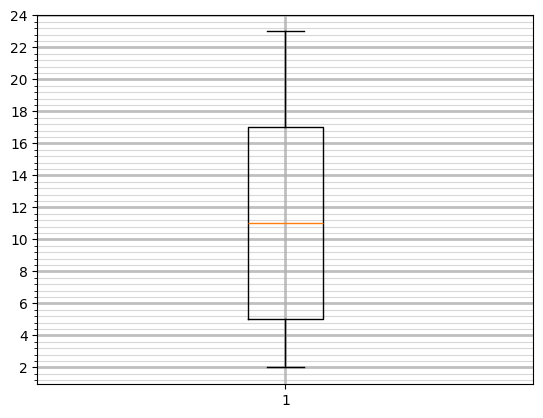

In [33]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np

def Cal_Q(a_data):
    l = len(a_data)
    l2 = l/2
    if l2 == int(l2): # 均分：前50%，后50%
        # 中位数计算：中间两个值的平均值
        Q = (a_data[int(l2)-1] + a_data[int(l2)])/2
        a_data1 = a_data[:int(l2)]
        a_data2 = a_data[int(l2):]
    else:
        # 中位数就是中间数值
        Q = a_data[int(l2)] 
        a_data1 = a_data[:int(l2)]
        a_data2 = a_data[int(l2)+1:]
    return Q, a_data1, a_data2


# 计算四分位
data =  [2, 3, 5, 7, 11, 13, 17, 19, 23]   # 长度9，
# data = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29]   # 长度10
data = sorted(data)
print(data)

Q2, data21, data22 = Cal_Q(data)
print(F"中位数计算：Q2={Q2:.2f}")
# print(F"\tdata1={data1}")
# print(F"\tdata1={data2}")

Q1, data41, data42 = Cal_Q(data21)
print(F"第一四分位计算：Q1={Q1:.2f}")
# print(F"\tdata1={data41}")
# print(F"\tdata1={data42}")

Q3, data43, data44 = Cal_Q(data22)
print(F"第三四分位计算：Q3={Q3:.2f}")
# print(F"\tdata1={data43}")
# print(F"\tdata1={data44}")

result = plt.boxplot(data)
plt.gca().yaxis.set_major_locator(plt.MultipleLocator(2))
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(5))
plt.grid(which='minor', alpha=0.5, linestyle='-')
plt.grid(which='major', alpha=0.8, linestyle='-', linewidth=2)
plt.show()


- 代码说明：
    - 我们使用grid函数绘制网格线的时候，使用which参数设置网格线的绘制与主刻度与次刻度对应，这样我们可以更加直观观察箱线图的数据。
        - `plt.gca().yaxis.set_major_locator(plt.MultipleLocator(0.5))` : 按照0.5间隔绘制主刻度。
        - `plt.gca().yaxis.set_minor_locator(AutoMinorLocator(5))`：主刻度之间，按照5等分绘制次刻度。
    - 上面的计算的Q1与在箱线图中的Q1显示不同，这是因为在R语言，Python语言（Panda与Numpy），Matlab语言中，使用的不是最早Tukey提出的计算方法，而是采用的插值计算方法。

- Q1，Q2，Q3的计算（方法二：线性插值法）：
  - 位置计算：
      - 位置 = $1 + (n - 1) \ast p$，其中n是数据样本数（数据长度），p是四分位的三个值25%,50%,75%，分别对应Q1，Q2，Q3
  - 四分位数计算：
      - 如果位置是整数，则四分位数就是该位置的值。
      - 如果位置不是整数，则计算公式是：$ (1-f) * x[k] + f * x[k+1]$，其中k是位置的整数部分，f是位置的小数部分。
  - 总结：
      - 使用线性插值法，则总体上更加符合数据的线性规律。 

[13, 13.5, 13.8, 13.9, 14, 14.6, 14.8, 15, 15.2, 15.4, 15.7]
中位数计算： 	Q2=14.80 ,	位置：6.0
第一四分位计算：	Q1=13.85 ,	位置：3.5
第三四分位计算：	Q3=15.10 ,	位置：8.5


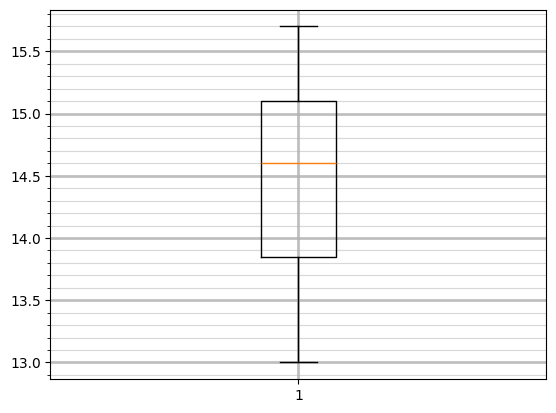

In [47]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np

def Cal_Q_linear(a_data, p):
    # 样本总数
    l = len(a_data)
    # 位置计算
    pos = 1 + (l-1) * p
    # 使用插值公式计算Q1
    if pos == int(pos): # 整数情况
        Q = a_data[int(pos)]
    else: # 小数情况
        k = int(pos)
        f = pos - int(pos)
        Q =  (1-f) * a_data[k-1] + f * a_data[k]
    return Q, pos


# 计算四分位
# data =  [2, 3, 5, 7, 11, 13, 17, 19, 23]   # 长度9，
# data = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29]   # 长度10
data = [13, 13.5, 13.8, 13.9, 14, 14.6, 14.8, 15, 15.2, 15.4, 15.7]
data = sorted(data)
print(data)

Q1, pos1 = Cal_Q_linear(data, 0.25)
Q2, pos2= Cal_Q_linear(data, 0.50)
Q3, pos3 = Cal_Q_linear(data, 0.75)
print(F"中位数计算： \tQ2={Q2:.2f}", F",\t位置：{pos2}")
print(F"第一四分位计算：\tQ1={Q1:.2f}", F",\t位置：{pos1}")
print(F"第三四分位计算：\tQ3={Q3:.2f}", F",\t位置：{pos3}")

result = plt.boxplot(data)
plt.gca().yaxis.set_major_locator(plt.MultipleLocator(0.5))
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(5))
plt.grid(which='minor', alpha=0.5, linestyle='-')
plt.grid(which='major', alpha=0.8, linestyle='-', linewidth=2)
plt.show()


- 代码说明：
    - 我们对比上面两个例子，可以看出来，在matplotlib中，boxplot函数中四分位的计算采用的是线性插值计算方法。
    - 我们把四分位的计算（包含位置计算），封装在函数Cal_Q_linear中实现，其中因为我们的数组下标从0开始，所以我们代码`Q =  (1-f) * a_data[k-1] + f * a_data[k]`中的计算公式与我们在说明列出的公式`(1-f) * x[k] + f * x[k+1]`，我们使用k-1自动与数组的下标保持一致。

- 通过boxplot返回对象来设置图表样式属性的例子
    - 在boxplot中，没有提供`**kwargs`这样的参数来设置绘制对象的属性，所以采用设置返回对象的属性可以达到同样效果，后面有专门主题来讲解常见图表对象的属性操作，我们这里简单举一个例子说明。

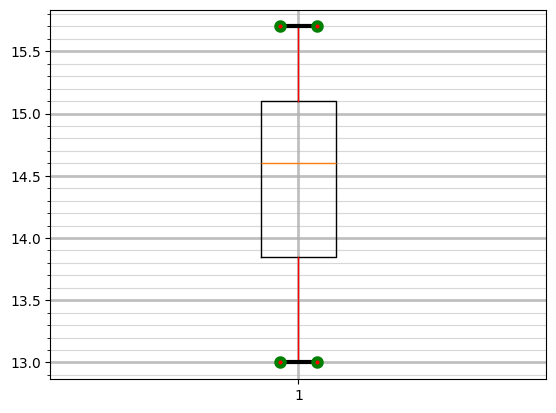

In [58]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np

data = [13, 13.5, 13.8, 13.9, 14, 14.6, 14.8, 15, 15.2, 15.4, 15.7]
data = sorted(data)


result = plt.boxplot(data)
##############################
# 获取result字典返回的对象，并设置属性
whiskers = result["whiskers"]
for whisker in whiskers:   # whisker对象是Line2D
    whisker.set_color("#FF0000FF")

caps = result["caps"]
for cap in caps:
    cap.set_linewidth(3)
    cap.set_marker("o")
    cap.set_markerfacecolor("red")
    cap.set_markeredgewidth(3)
    cap.set_markeredgecolor("green")
###############################
plt.gca().yaxis.set_major_locator(plt.MultipleLocator(0.5))
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(5))
plt.grid(which='minor', alpha=0.5, linestyle='-')
plt.grid(which='major', alpha=0.8, linestyle='-', linewidth=2)
plt.show()


- 须线位置的计算：
    - 计算IQR：四分位距（Interquartile Range, IQR），IQR是箱体高度。
        - 计算公式：IQR = Q3 - Q1
    - 计算须线的上限与下限：（这个计算公式也有不同的计算标准）
        - 上限值：Q3 + 1.5 * IQR
        - 下限值：Q1 - 1.5 * IQR
    - 计算须线的端点值
        - 上端点值：min(数据最大值, 上限值)
        - 下端点值：max(数据最小值，下限值) 

中位数计算： 	Q2=14.80 ,	位置：6.0
第一四分位计算：	Q1=13.85 ,	位置：3.5
第三四分位计算：	Q3=15.10 ,	位置：8.5
箱体高度：1.25
上限值：16.97
下限值：11.98
上须线端点值:15.7
下须线端点值:13


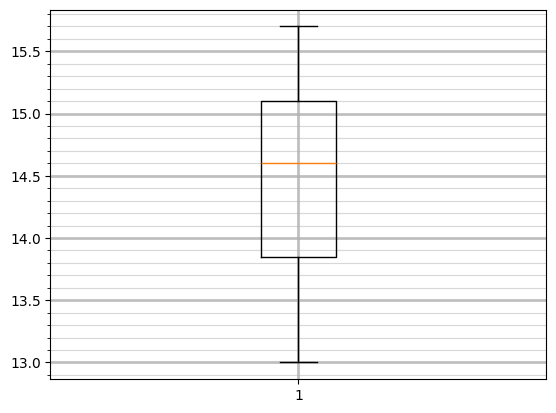

In [59]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np

def Cal_Q_linear(a_data, p):
    # 样本总数
    l = len(a_data)
    # 位置计算
    pos = 1 + (l-1) * p
    # 使用插值公式计算Q1
    if pos == int(pos): # 整数情况
        Q = a_data[int(pos)]
    else: # 小数情况
        k = int(pos)
        f = pos - int(pos)
        Q =  (1-f) * a_data[k-1] + f * a_data[k]
    return Q, pos


# 计算四分位
# data =  [2, 3, 5, 7, 11, 13, 17, 19, 23]   # 长度9，
# data = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29]   # 长度10
data = [13, 13.5, 13.8, 13.9, 14, 14.6, 14.8, 15, 15.2, 15.4, 15.7]
data = sorted(data)

Q1, pos1 = Cal_Q_linear(data, 0.25)
Q2, pos2= Cal_Q_linear(data, 0.50)
Q3, pos3 = Cal_Q_linear(data, 0.75)
print(F"中位数计算： \tQ2={Q2:.2f}", F",\t位置：{pos2}")
print(F"第一四分位计算：\tQ1={Q1:.2f}", F",\t位置：{pos1}")
print(F"第三四分位计算：\tQ3={Q3:.2f}", F",\t位置：{pos3}")

# 计算IQR
IQR = Q3 - Q1
print(F"箱体高度：{IQR:.2f}")
# 计算上、下限值
upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 * IQR
print(F"上限值：{upper:.2f}")
print(F"下限值：{lower:.2f}")
# 计算须线
upper_whisker = min(upper, max(data))
lower_whisker = max(lower, min(data))
print(F"上须线端点值:{upper_whisker}")
print(F"下须线端点值:{lower_whisker}")

result = plt.boxplot(data)
plt.gca().yaxis.set_major_locator(plt.MultipleLocator(0.5))
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(5))
plt.grid(which='minor', alpha=0.5, linestyle='-')
plt.grid(which='major', alpha=0.8, linestyle='-', linewidth=2)
plt.show()


- 代码说明：
    - 须线的两个端点值，实际是由数据的最大最小值，以及以箱体高度和四分位决定的。
    - `upper = Q3 + 1.5 * IQR`计算上限值，`lower = Q1 - 1.5 * IQR`计算下限值
    - `upper_whisker = min(upper, max(data))`计算的是须线的上边界端点值，`lower_whisker = max(lower, min(data))`计算的虚线的下边界端点值。也是我们看到的须线的边界值。
    - 这里的1.5可以根据情况确定的值，之所以使用1.5是因为统计学上的意义：
        - 在正态分布中，约有0.7%的数据点会落在1.5倍IQR之外，这是选在1.5的统计学依据，1.5 * IQR规则其实也是一个经验法则。
        - 1.5这个值的设置可以使用whis参数设置，默认是1.5，该参数类型是float。
    - 任何在须线外的值都是异常值，根据我们上面须线的上下边界端点的计算，出现异常值只有下面两种情况：
        - 上限值**小于**数据样本的最大值：异常值 = 样本值 > Q3+1.5×IQR（上限值）。
        - 下限值**大于**数据样本的最小值：异常值 = 样本值 < Q1-1.5×IQR（下限值）
    - 因为上下限值是根据Q1，Q3与IQR（箱体高度）计算的，所以在matplotlib中，异常值都是超出4个箱高以外的值，或者说是离中心点2个箱高外的值。

- 出现异常值的例子：
    - 异常值在boxplot函数中使用fliers单词表示。

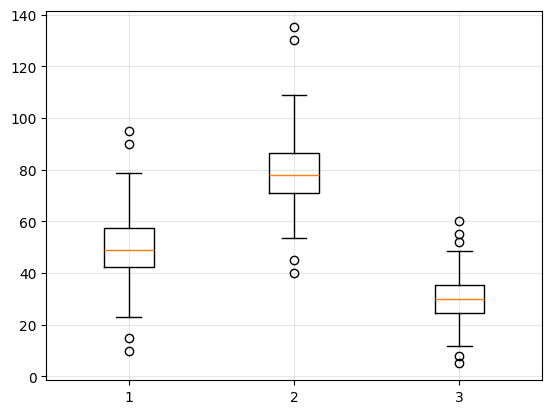

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# 使用正态分布取值，后面部分的值是故意设置的异常值。
data1 = np.concatenate([np.random.normal(50, 10, 100), [10, 15, 90, 95]])
data2 = np.concatenate([np.random.normal(80, 12, 100), [40, 45, 130, 135]])
data3 = np.concatenate([np.random.normal(30, 8, 100), [5, 8, 55, 60]])

all_data = [data1, data2, data3]

plt.boxplot(all_data)
plt.grid(True, alpha=0.3)
plt.show()


- 参数notch的使用：
    - notch=True：在箱体中间创建一个缺口，表示中位数的置信区间
    - notch=False：显示标准的矩形箱体（**默认**）
    - 当两个箱线图的缺口不重叠时，可以认为它们的中位数在统计上有显著差异（约95%置信水平）。
    - 与notch参数有关的参数是conf_intervals，可以在notch=True的时候，指定置信区间，如果conf_intervals=None，则使用bootstrap等参数计算。
        - conf_intervals参数是(len(x), 2)的二维数组，用来指定每个箱体的置信区间缺口。

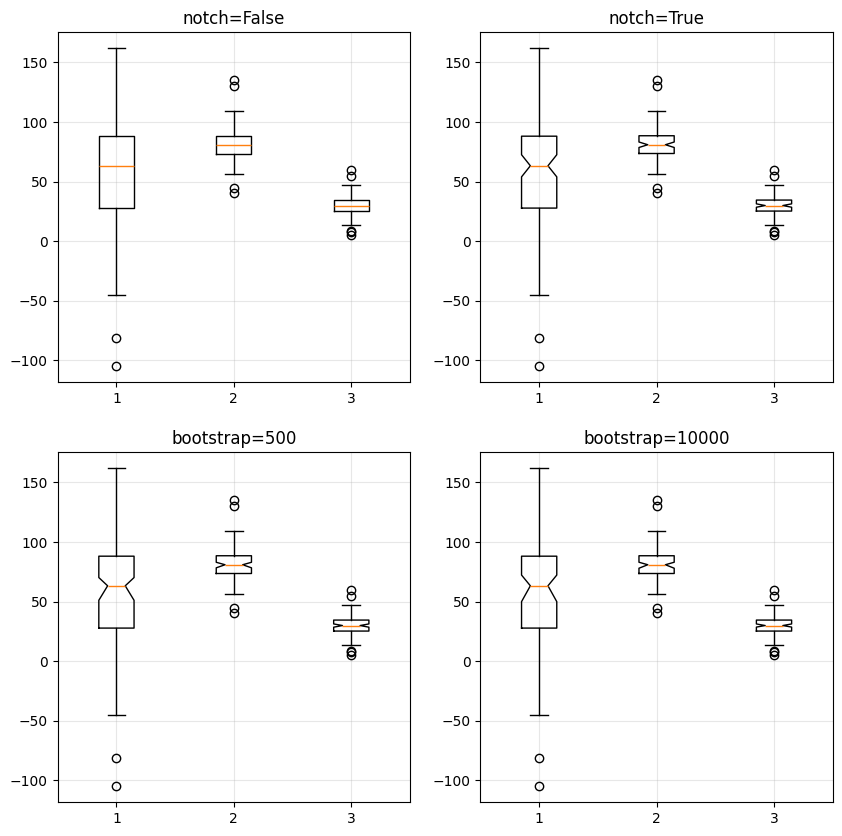

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# 使用正态分布取值，后面部分的值是故意设置的异常值。
data1 = np.concatenate([np.random.normal(50, 50, 100), [10, 15, 90, 95]])
data2 = np.concatenate([np.random.normal(80, 12, 100), [40, 45, 130, 135]])
data3 = np.concatenate([np.random.normal(30, 8, 100), [5, 8, 55, 60]])

all_data = [data1, data2, data3]

plt.figure(figsize=(10, 10))

plt.subplot(221)
plt.boxplot(all_data)  # 默认notch=False
plt.title("notch=False")
plt.grid(True, alpha=0.3)

plt.subplot(222)
plt.boxplot(all_data, notch=True)
plt.title("notch=True")
plt.grid(True, alpha=0.3)

plt.subplot(223)
plt.boxplot(all_data, notch=True, bootstrap=500)
plt.title("bootstrap=500")
plt.grid(True, alpha=0.3)

plt.subplot(224)
plt.boxplot(all_data, notch=True, bootstrap=10000)
plt.title("bootstrap=10000")
plt.grid(True, alpha=0.3)


plt.show()



- 代码说明：
    - `np.random.normal(50, 50, 100)`代码总，第一个参数50表示均值，第二个参数50表示方差是50，方差决定了数据的分散程度，均值决定了数据的中心位置（中位数位置）
    - 影响置信区间计算的还有一个参数bootstrap，是指有放回抽样的次数，该参数类型是整数，指定采样次数（有放回）。采样次数越多，置信区间更具有统计学上的意义。找个值一般建议在1000与10000之间。
        - bootstrap指定次数下，计算速度快，指定次数大，计算就越精确，指定为None，则基于正态分布计算（接近正态分布）

- usermedians参数的使用
    - 使用用户指定的中位数，这个在某些情况下具有特别作用，比如指定某个标准中位数，而不是实际数据计算出来的中位数。这样可以参考标准值来分析用户数据。
    - 该参数可以配合notch参数，showmeans参数,meanline参数使用：
        - showmeans显示计算的中位数，默认使用插入符标识。
        - meanline参数指定使用线段来标识计算的中位数。

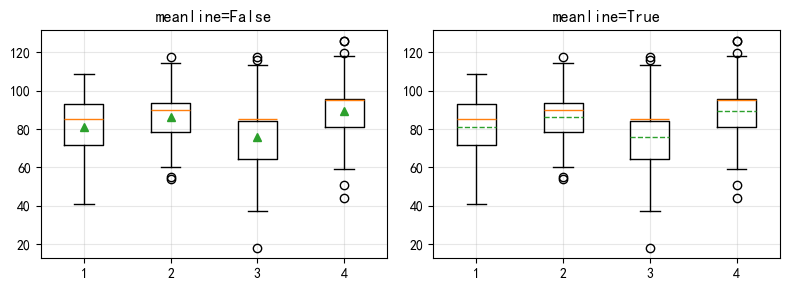

In [85]:
import matplotlib.pyplot as plt
import numpy as np

# 业务场景：销售目标 vs 实际业绩分析
np.random.seed(2024)

# 生成各季度销售数据
q1_sales = np.random.normal(80, 15, 90)
q2_sales = np.random.normal(85, 12, 90)
q3_sales = np.random.normal(78, 18, 90)
q4_sales = np.random.normal(92, 14, 90)

sales_data = [q1_sales, q2_sales, q3_sales, q4_sales]

# 公司设定的销售目标中位数
sales_targets = [85, 90, 85, 95]   # 中位数指定

plt.figure(figsize=(8, 3))

# 创建箱线图，使用目标作为中位数
plt.subplot(121)
plt.boxplot(sales_data, 
                usermedians=sales_targets,
                showmeans=True,
                meanline=False)
plt.title('meanline=False')
plt.grid(True, alpha=0.3)

plt.subplot(122)
plt.boxplot(sales_data, 
                usermedians=sales_targets,
                showmeans=True,
                meanline=True)
plt.title('meanline=True')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


- 箱体控制参数说明：
    - widths：控制箱体的宽度，参数为float（所有箱体一样宽度）或者与x一样长度的数组（用来指定多个箱体不同的宽度），默认值是0.5，或者`0.15*(箱体位置之间距离)`
    - positions：用来指定箱体位置，参数类型数数组，用来指定每个箱体在x轴定位位置，默认是range(1, N+1)的位置。
    - patch_artist：参数类型是bool类型，如果为True，则使用可填充的Patch对象来绘制（可以填充颜色），否则采用Line2D绘制（空心，不可填充颜色）。
    - tick_labels：每个箱体的x轴刻度标签。在V3.9以后，该参数替换成Labels，目前为了兼容，还保留该参数。

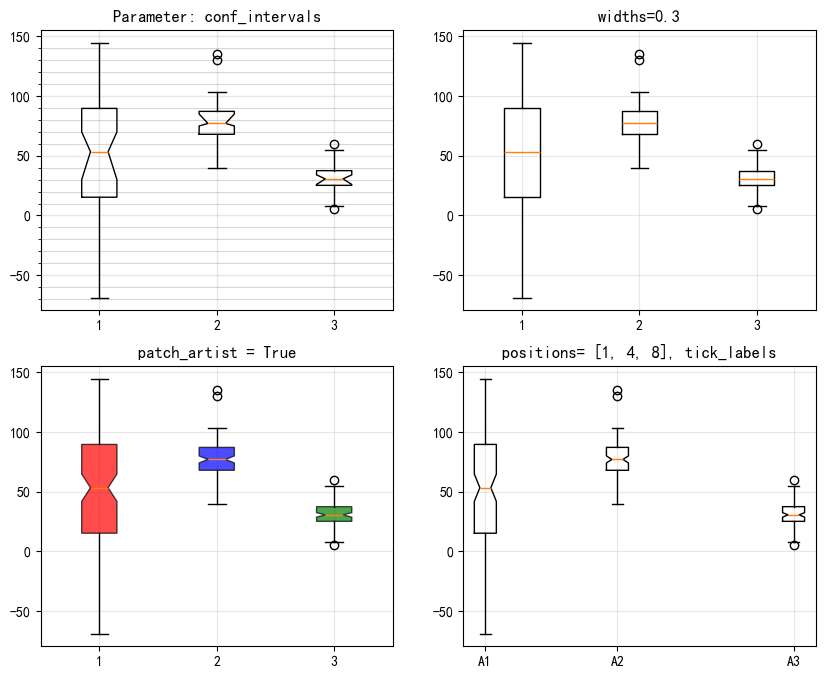

In [108]:
import matplotlib.pyplot as plt
import numpy as np

# 使用正态分布取值，后面部分的值是故意设置的异常值。
data1 = np.concatenate([np.random.normal(50, 50, 100), [10, 15, 90, 95]])
data2 = np.concatenate([np.random.normal(80, 12, 100), [40, 45, 130, 135]])
data3 = np.concatenate([np.random.normal(30, 8, 100), [5, 8, 55, 60]])

data = [data1, data2, data3]

plt.figure(figsize=(10, 8))

conf_intervals = [(50-20, 50+20), (80-5, 80+5), (30-4, 30+ 4)]
plt.subplot(221)
plt.boxplot(data, notch=True, conf_intervals=conf_intervals)  # 默认notch=False
plt.title("Parameter: conf_intervals")
plt.gca().yaxis.set_major_locator(plt.MultipleLocator(50))
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(5))
plt.grid(which='minor', alpha=0.5, linestyle='-')
plt.grid(which='major', alpha=0.8, linestyle='-', linewidth=1)
plt.grid(True, alpha=0.3)

plt.subplot(222)
plt.boxplot(data, widths=0.3)
plt.title("widths=0.3")
plt.grid(True, alpha=0.3)

plt.subplot(223)
result = plt.boxplot(data, notch=True, patch_artist=True)
plt.title("patch_artist = True")
plt.grid(True, alpha=0.3)
#########################################通过返回的对象进行属性设置
for patch, color in zip(result['boxes'], ["red", "blue", "green"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')
    patch.set_linewidth(1)
#########################################

plt.subplot(224)
positions = [1, 4, 8]
plt.boxplot(data, notch=True, positions=positions, tick_labels=["A1", "A2", "A3"])  # 3.9版本之前，请使用labels
plt.title("positions= [1, 4, 8], tick_labels")
plt.grid(True, alpha=0.3)


plt.show()



- 代码说明：
    - 上面我们分别对几个参数的使用进行了说明，其中还有一个有关的参数manage_ticks，用来调整x轴的标签刻度。默认值是True，可以设置为False不进行调整管理。

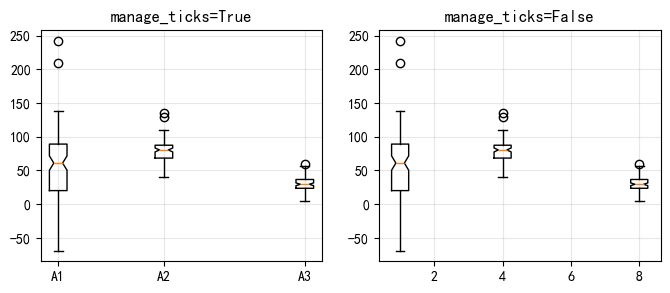

In [109]:
import matplotlib.pyplot as plt
import numpy as np

# 使用正态分布取值，后面部分的值是故意设置的异常值。
data1 = np.concatenate([np.random.normal(50, 50, 100), [10, 15, 90, 95]])
data2 = np.concatenate([np.random.normal(80, 12, 100), [40, 45, 130, 135]])
data3 = np.concatenate([np.random.normal(30, 8, 100), [5, 8, 55, 60]])

data = [data1, data2, data3]

plt.figure(figsize=(8, 3))


plt.subplot(121)
positions = [1, 4, 8]
plt.boxplot(data, notch=True, positions=positions, tick_labels=["A1", "A2", "A3"], manage_ticks=True)  # 3.9版本之前，请使用labels
plt.title("manage_ticks=True")
plt.grid(True, alpha=0.3)

plt.subplot(122)
positions = [1, 4, 8]
plt.boxplot(data, notch=True, positions=positions, tick_labels=["A1", "A2", "A3"], manage_ticks=False)  # 3.9版本之前，请使用labels
plt.title("manage_ticks=False")
plt.grid(True, alpha=0.3)

plt.show()



- 代码说明：
    - manage_ticks参数使用默认值，符合大部分的使用场景，定制程度要高。而且manage_ticks=False的时候，tick_labels参数没有作用。
    - 在某些情况下tick_labels=False的情况，可以更好的体现位置，如果位置也具有某种意义的话，使用False值肯定是更好的选择。

- autorange参数说明：
    - autorange=False 使用标准的箱线图范围计算，autorange=True 当存在异常值时自动调整须线范围
    - 适用于包含极端异常值的数据可视化。这类调整须线范围也有相应的数学计算方法，我们这里不详细介绍数学计算原理，我们使用下面例子来对比体验可视化效果(包括调整的数学计算，调整的变化比较细微)。

=== 数据统计 ===
总数据点: 97
主要数据范围: [60.70, 127.78]
极端异常值: [200   5]

=== 标准计算 (autorange=False) ===
Q1: 90.97
Q3: 107.70
IQR: 16.72
理论下限: 65.89
理论上限: 132.79
实际下限须线: 70.19
实际上限须线: 127.78

内点数据数量: 94
内点数据范围: [70.19, 127.78]

=== 自动范围计算 (autorange=True) ===
内点数据均值: 98.94
内点数据标准差: 13.22
乘数因子: 2.698 (对应99%置信区间)
调整后理论下限: 63.27
调整后理论上限: 134.62
实际下限须线: 63.27
实际上限须线: 134.62

验证: 99%置信区间的理论z分数: 2.576
实际使用的乘数: 2.698


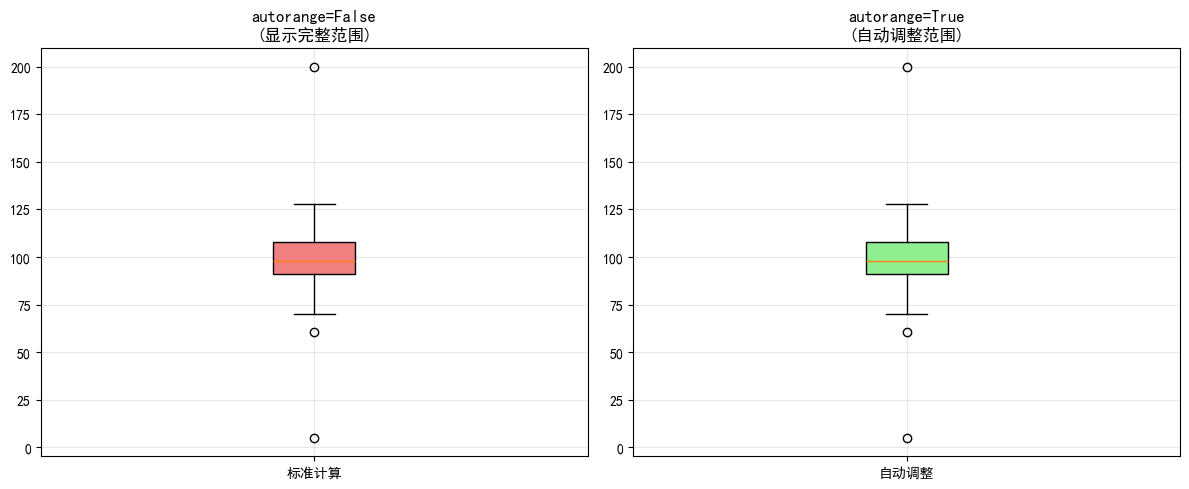

In [116]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

def detailed_autorange_calculation():
    """详细演示 autorange 的计算过程"""
    
    # 生成包含极端异常值的数据
    np.random.seed(42)
    main_data = np.random.normal(100, 15, 95)
    # extreme_outliers = np.array([500, 600, 400, -100, -150])
    extreme_outliers = np.array([150, 5])
    data = np.concatenate([main_data, extreme_outliers])
    
    print("=== 数据统计 ===")
    print(f"总数据点: {len(data)}")
    print(f"主要数据范围: [{main_data.min():.2f}, {main_data.max():.2f}]")
    print(f"极端异常值: {extreme_outliers}")
    
    # 标准计算方法 (autorange=False)
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound_std = Q1 - 1.5 * IQR
    upper_bound_std = Q3 + 1.5 * IQR
    
    # 找到标准方法下的须线实际位置
    data_sorted = np.sort(data)
    lower_whisker_std = data_sorted[data_sorted >= lower_bound_std][0]
    upper_whisker_std = data_sorted[data_sorted <= upper_bound_std][-1]
    
    print("\n=== 标准计算 (autorange=False) ===")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"理论下限: {lower_bound_std:.2f}")
    print(f"理论上限: {upper_bound_std:.2f}")
    print(f"实际下限须线: {lower_whisker_std:.2f}")
    print(f"实际上限须线: {upper_whisker_std:.2f}")
    
    # autorange=True 计算方法
    # 步骤1: 筛选内点数据（在标准边界内的数据）
    inlier_mask = (data >= lower_bound_std) & (data <= upper_bound_std)
    inlier_data = data[inlier_mask]
    
    print(f"\n内点数据数量: {len(inlier_data)}")
    print(f"内点数据范围: [{inlier_data.min():.2f}, {inlier_data.max():.2f}]")
    
    if len(inlier_data) > 0:
        # 步骤2: 计算内点数据的统计量
        mean_inliers = np.mean(inlier_data)
        std_inliers = np.std(inlier_data)
        
        # 步骤3: 使用基于标准差的调整
        # 2.698 对应正态分布下99%的置信区间
        # 因为 P(|Z| < 2.698) ≈ 0.99，其中 Z ~ N(0,1)
        multiplier = 2.698  # 对应99%置信水平
        
        adjusted_lower = mean_inliers - multiplier * std_inliers
        adjusted_upper = mean_inliers + multiplier * std_inliers
        
        # 步骤4: 确保调整后的值在数据范围内
        lower_whisker_auto = max(np.min(data), adjusted_lower)
        upper_whisker_auto = min(np.max(data), adjusted_upper)
        
        print("\n=== 自动范围计算 (autorange=True) ===")
        print(f"内点数据均值: {mean_inliers:.2f}")
        print(f"内点数据标准差: {std_inliers:.2f}")
        print(f"乘数因子: {multiplier} (对应99%置信区间)")
        print(f"调整后理论下限: {adjusted_lower:.2f}")
        print(f"调整后理论上限: {adjusted_upper:.2f}")
        print(f"实际下限须线: {lower_whisker_auto:.2f}")
        print(f"实际上限须线: {upper_whisker_auto:.2f}")
        
        # 验证计算
        z_score = stats.norm.ppf(0.995)  # 双尾99%的z分数
        print(f"\n验证: 99%置信区间的理论z分数: {z_score:.3f}")
        print(f"实际使用的乘数: {multiplier}")
    
    # 可视化对比
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # autorange=False
    bp1 = ax1.boxplot([data], tick_labels=['标准计算'], autorange=False, patch_artist=True)
    ax1.set_title('autorange=False\n(显示完整范围)')
    ax1.grid(True, alpha=0.3)
    
    # autorange=True
    bp2 = ax2.boxplot([data], tick_labels=['自动调整'], autorange=True, patch_artist=True)
    ax2.set_title('autorange=True\n(自动调整范围)')
    ax2.grid(True, alpha=0.3)
    
    # 设置样式
    for box in bp1['boxes']:
        box.set_facecolor('lightcoral')
    for box in bp2['boxes']:
        box.set_facecolor('lightgreen')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'standard': (lower_whisker_std, upper_whisker_std),
        'autorange': (lower_whisker_auto, upper_whisker_auto) if len(inlier_data) > 0 else None
    }

# 执行计算
results = detailed_autorange_calculation()

- boxplot函数的外观样式设置参数：
    - 控制组件显示的参数，参数类型是bool，True为显示，False为不显示。
        - showcaps：是否显示须线帽盖。
        - showbox：是否显示箱体。
        - showfliers：是否显示异常点。
        - showmeans：是否显示均值。
    - 设置须线帽盖宽度：
        - capwidths：参数类型是float（每个箱子的虚线帽盖使用一样的宽度值）或者float数组（每个箱子的虚线帽盖使用不同的宽度）。
    - 设置各个组件的属性，参数类型都是dict字典类型，其中的key来自返回对象的属性，其中大部分组件都是Line2D对象。
        - capprops：Line2D对象的属性
        - boxprops：当使用patch_artist=True，则是Patch对象的属性，否则就是Line2D对象的属性。
        - whiskerprops：Line2D对象的属性
        - flierprops：Line2D对象的属性
        - medianprops：Line2D对象的属性
        - meanprops：Line2D对象的属性

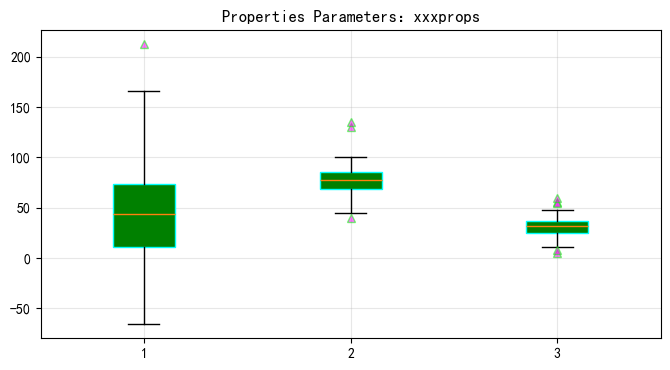

In [130]:
import matplotlib.pyplot as plt
import numpy as np

# 使用正态分布取值，后面部分的值是故意设置的异常值。
data1 = np.concatenate([np.random.normal(50, 50, 100), [10, 15, 90, 95]])
data2 = np.concatenate([np.random.normal(80, 12, 100), [40, 45, 130, 135]])
data3 = np.concatenate([np.random.normal(30, 8, 100), [5, 8, 55, 60]])

data = [data1, data2, data3]
plt.figure(figsize=(8, 4))

positions = [1, 4, 8]
plt.boxplot(data, 
            flierprops={
                "marker": "^",
                "markerfacecolor": "#FF00FF88",
                "markeredgecolor": "#00FF0088", 
            },
            boxprops={
                "facecolor": "green",
                "linestyle": ":",   # 使用ls别名会报警告。
                "ec": "cyan",
            },
            patch_artist=True
) 
plt.title("Properties Parameters：xxxprops")
plt.grid(True, alpha=0.3)


plt.show()



- 代码说明：
    - 使用xxxprops参数只能设置统一样式，如果想每个箱子的样式不同，就是用boxplot函数返回的对象。
    - 后面对对象属性会使用专门主题介绍。

### (3) 小提琴图绘制-violinplot

- 小提琴图表实际四箱线图的另外一种形式的数据呈现，其中的很多概念与boxplot中的概念一样。
    - violinplot展示数据的分布形状及其概率密度，重点体验分布形状与概率密度的绘制。

- violinplot函数原型定义与参数说明：

```python
matplotlib.pyplot.violinplot(
    dataset,    # 数据集
    positions=None,  # 小提琴的位置
    *, 
    vert=None,   # 方向，该参数不推荐使用，使用orientation替代。
    orientation='vertical',  
    widths=0.5,    # 小提琴宽度
    showmeans=False,   # 显示平均数
    showextrema=True,  # 显示极值
    showmedians=False, # 显示中位数
    quantiles=None,    # 设置分位数（一般是自动计算）
    points=100,  # 评估高斯核密度估计的数据点数。
    bw_method=None, # 控制核密度估计的带宽方法。取值{'scott', 'silverman'} 或者float或者可调用对象或者函数，默认值是'scott'。
    side='both', # 绘制的内容，在绘制位置的上面与下面都绘制，还是只绘制上面，或者下面。取值：{'both', 'low', 'high'}, 默认both
    data=None)
```

- 首先我们通过一个例子直观体验violinplot函数绘制的图表。
    - 其中dataset是必须的参数，该参数在`*`分隔参数前面，表示使用方式可以是关键字参数，或者位置参数。
    - dataset参数的数据类型是向量序列或者数组，与boxplot函数的参数一样。（我们借用boxplot中的数据生成方法）

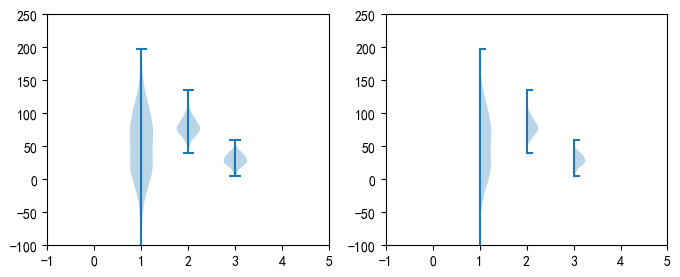

In [142]:
import matplotlib.pyplot as plt
import numpy as np

# 使用正态分布取值，后面部分的值是故意设置的异常值。
data1 = np.concatenate([np.random.normal(50, 50, 100), [10, 15, 90, 95]])
data2 = np.concatenate([np.random.normal(80, 12, 100), [40, 45, 130, 135]])
data3 = np.concatenate([np.random.normal(30, 8, 100), [5, 8, 55, 60]])

data = [data1, data2, data3]
plt.figure(figsize=(8, 3))

plt.subplot(121)
plt.violinplot(dataset=data)
plt.xlim(-1, 5)
plt.ylim(-100, 250)

plt.subplot(122)
plt.violinplot(dataset=data, side="high")
plt.xlim(-1, 5)
plt.ylim(-100, 250)

plt.show()

- 代码说明：
    - 生成的数据中，都根据经验添加了异常值，可以去掉异常值看看图表的变化。
    - 直观低根据图形，可以看出数据的分布情况。

- 比较直方图与小提琴图的分布效果。

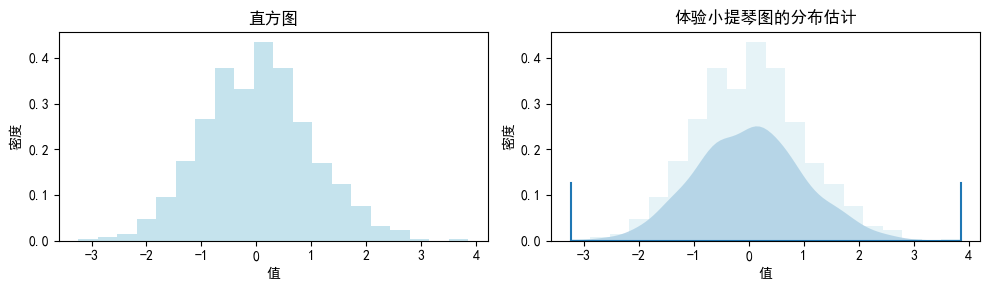

In [189]:
import numpy as np
import matplotlib.pyplot as plt


# 生成示例数据
np.random.seed(42)
data = np.random.normal(0, 1, 1000)

# 绘制比较图
plt.figure(figsize=(10, 3))

# 原始数据分布
plt.subplot(1, 2, 1)
plt.hist(data, bins=20, density=True, alpha=0.7, color='lightblue')
plt.title('直方图')
plt.xlabel('值')
plt.ylabel('密度')

plt.subplot(1, 2, 2)
plt.violinplot(data, orientation="horizontal", side="high", positions=[0])
plt.hist(data, bins=20, density=True, alpha=0.3, color='lightblue')
plt.title('体验小提琴图的分布估计')
plt.xlabel('值')
plt.ylabel('密度')


plt.tight_layout()
plt.show()

- 代码说明
    - 在代码中我们提前使用了直方图来直观比较数据的分布情况。
    - 我们这里不解释小琴题图计算的数学原理，我们仅仅使用一段代码来说明计算过程。感兴趣的可以通过代码来了解其计算的数学原理与公式：

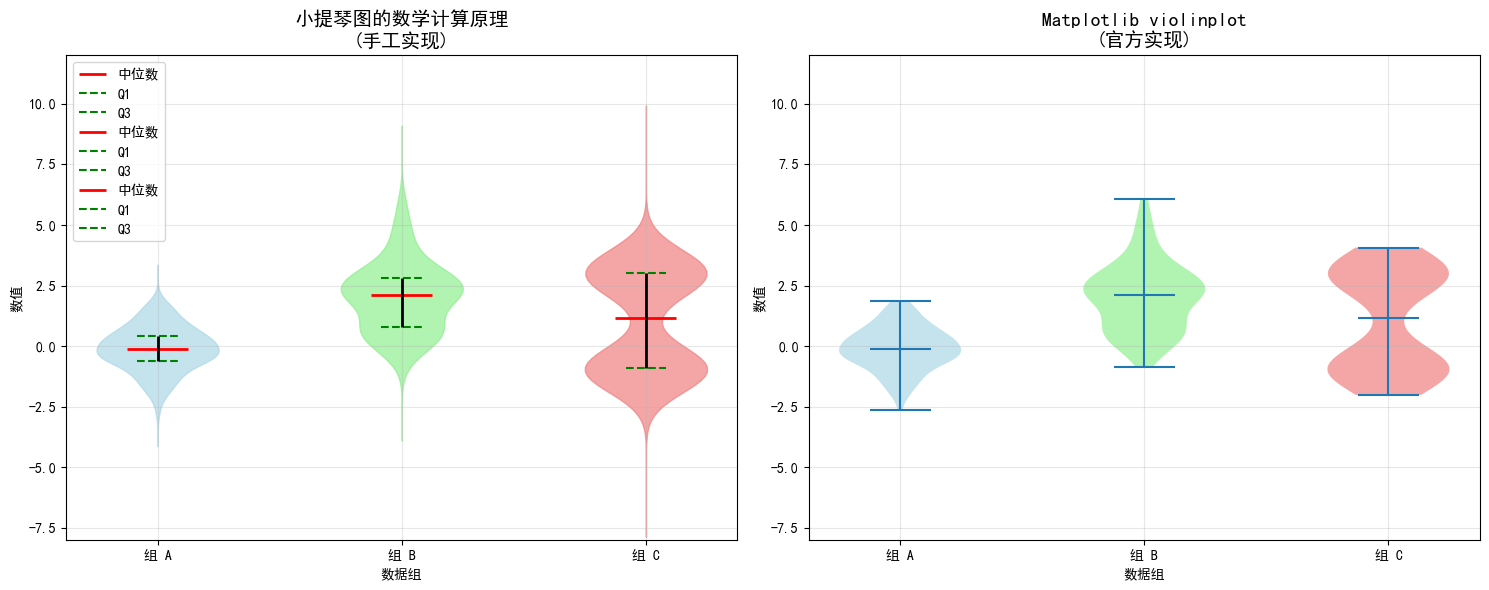

In [194]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def create_violin_plot_manual(data, ax, position=0, width=0.8, color='blue'):
    """
    手动构建小提琴图的各个组件
    """
    # 1. 计算核密度估计
    kde = gaussian_kde(data)
    
    # 2. 确定数据范围（扩展到数据的 1.5 倍 IQR）
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    lower_bound = np.min(data) - 1.5 * iqr
    upper_bound = np.max(data) + 1.5 * iqr
    
    # 3. 创建密度网格
    x_grid = np.linspace(lower_bound, upper_bound, 100)
    density = kde(x_grid)
    
    # 4. 归一化密度到小提琴宽度
    max_density = np.max(density)
    normalized_density = (density / max_density) * (width / 2)
    
    # 5. 绘制小提琴主体
    ax.fill_betweenx(x_grid, 
                    position - normalized_density, 
                    position + normalized_density, 
                    alpha=0.7, color=color)
    
    # 6. 添加统计信息
    # 中位数
    median = np.median(data)
    ax.hlines(median, position - width/4, position + width/4, 
              colors='red', linewidths=2, label='中位数')
    
    # 四分位数
    q1, q3 = np.percentile(data, [25, 75])
    ax.hlines(q1, position - width/6, position + width/6, 
              colors='green', linewidths=1.5, linestyles='--', label='Q1')
    ax.hlines(q3, position - width/6, position + width/6, 
              colors='green', linewidths=1.5, linestyles='--', label='Q3')
    
    # 箱体
    ax.vlines(position, q1, q3, colors='black', linewidths=2)
    
    return {
        'median': median,
        'q1': q1,
        'q3': q3,
        'density': density,
        'x_grid': x_grid
    }

# 生成多组数据
np.random.seed(42)
data_sets = [
    np.random.normal(0, 1, 100),
    np.random.normal(2, 1.5, 100),
    np.concatenate([np.random.normal(-1, 0.5, 50), 
                   np.random.normal(3, 0.5, 50)])  # 双峰分布
]

# 绘制手动构建的小提琴图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 手动构建
colors = ['lightblue', 'lightgreen', 'lightcoral']
for i, data in enumerate(data_sets):
    stats_info = create_violin_plot_manual(data, ax1, position=i+1, 
                                         width=0.5, color=colors[i])

ax1.set_title('小提琴图的数学计算原理\n(手工实现)', fontsize=14)
ax1.set_xlabel('数据组')
ax1.set_ylabel('数值')
ax1.set_ylim(-8, 12)
ax1.set_xticks([1, 2, 3])
ax1.set_xticklabels(['组 A', '组 B', '组 C'])
ax1.legend()
ax1.grid(True, alpha=0.3)

# 使用 matplotlib 的 violinplot 对比
violin_parts = ax2.violinplot(data_sets, showmedians=True, showextrema=True)
for i, pc in enumerate(violin_parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.7)

ax2.set_title('Matplotlib violinplot\n(官方实现)', fontsize=14)
ax2.set_xlabel('数据组')
ax2.set_ylabel('数值')
ax2.set_ylim(-8, 12)
ax2.set_xticks([1, 2, 3])
ax2.set_xticklabels(['组 A', '组 B', '组 C'])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- 代码说明：
    - 上面代码页借助了numpy，scipy等模块中的实现来计算，我们大致可以列出计算过程与相应的数学公式：
        - 核密度估计的基本公式：对于一组数据点 $x_1, x_2, ..., x_n$，在任意点 $x$ 处的核密度估计为：
            - $f_h(x) = \dfrac{1}{hn} \sum _{i=1}^{n} \limits K(\dfrac{x-x_i}{h})$
            - 其中h是带宽，n是样本个数，K是正态分布函数（高斯核函数：$K(\mu) = \dfrac{1}{\sqrt{2 \pi}} e^{-\frac{1}{2}\mu ^ 2}$）
        - 带宽的计算有两种方式：
            - Scott规则：$h = 1.059 \cdot \min (\delta, \frac{IQR}{1.349}) \cdot n^{-\frac{1}{5}} $
            - Silverman规则：$h = 0.9 \cdot \min (\delta, \frac{IQR}{1.349}) \cdot n^{-\frac{1}{5}} $
            - 其中$\delta$是样本点的标准方差。

- 有了上面的理解，其他参数的使用比较简单：
    - showmeans=False,   # 显示平均数
    - showextrema=True,  # 显示极值
    - showmedians=False, # 显示中位数

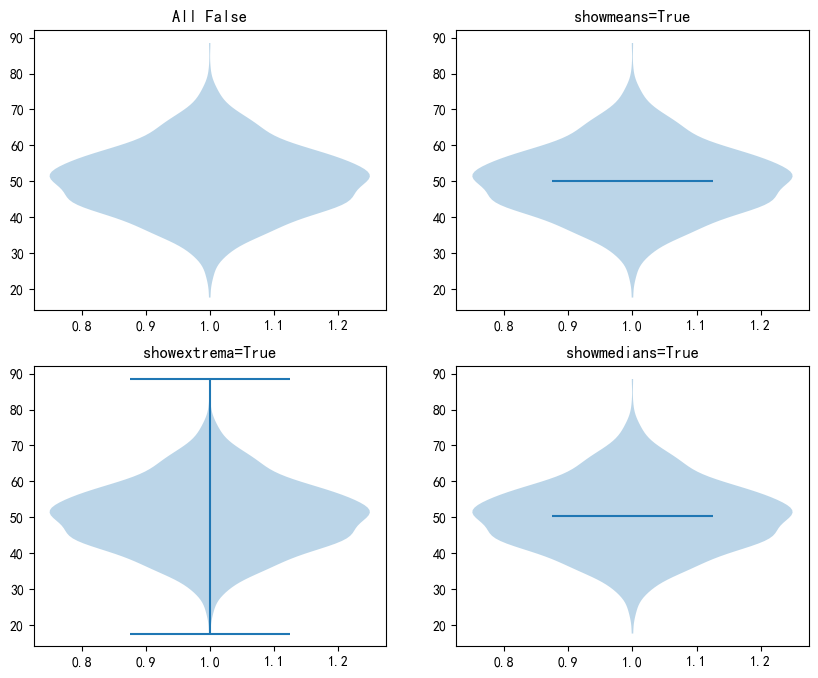

In [201]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
# 生成示例数据
np.random.seed(42)
data = np.random.normal(50, 10, 1000)

plt.subplot(221)
plt.violinplot(data, showmeans=False, showextrema=False, showmedians=False)
plt.title("All False")

plt.subplot(222)
plt.violinplot(data, showmeans=True, showextrema=False, showmedians=False)
plt.title("showmeans=True")

plt.subplot(223)
plt.violinplot(data, showmeans=False, showextrema=True, showmedians=False)
plt.title("showextrema=True")

plt.subplot(224)
plt.violinplot(data, showmeans=False, showextrema=False, showmedians=True)
plt.title("showmedians=True")
plt.show()

- 代码说明：
    - 上面数据的均值与中位数比较接近。

- 函数的返回值说明
    - 与其他绘制函数一样，该函数也返回绘制的组件对象，通过这些对象，可以设置每个组件的属性。返回值是字典类型，其中关键字映射的对象说明：
        - bodies: 小提琴主要区域，是PolyCollection对象。
        - cmeans: LineCollection对象,可视化均值
        - cmins: LineCollection对象，分布的底部.
        - cmaxes: LineCollection对象，分布的顶部.
        - cbars: LineCollection对象，小提琴中心.
        - cmedians: LineCollection对象，小提琴中位数.
        - cquantiles: LineCollection对象，可视化分位数.

## 3.5. 分箱图

- 分箱图相关的绘制，主要是直方图的绘制：
    - hexbin函数：将平面划分为六边形区域，能更效地利用空间，避免方向性偏差。
        - 绘制六边形图。
    - hist函数：经典的单变量分布图，可显示频率或密度。
        - 绘制柱状图。
    - hist2d函数：将平面划分为矩形区域，用颜色表示点的密度。
        - 绘制二维热力图。
    - stairs函数：hist 的“无填充”版本，更强调分布轮廓。
        - 绘制阶梯图。

- 各个函数的效果比较

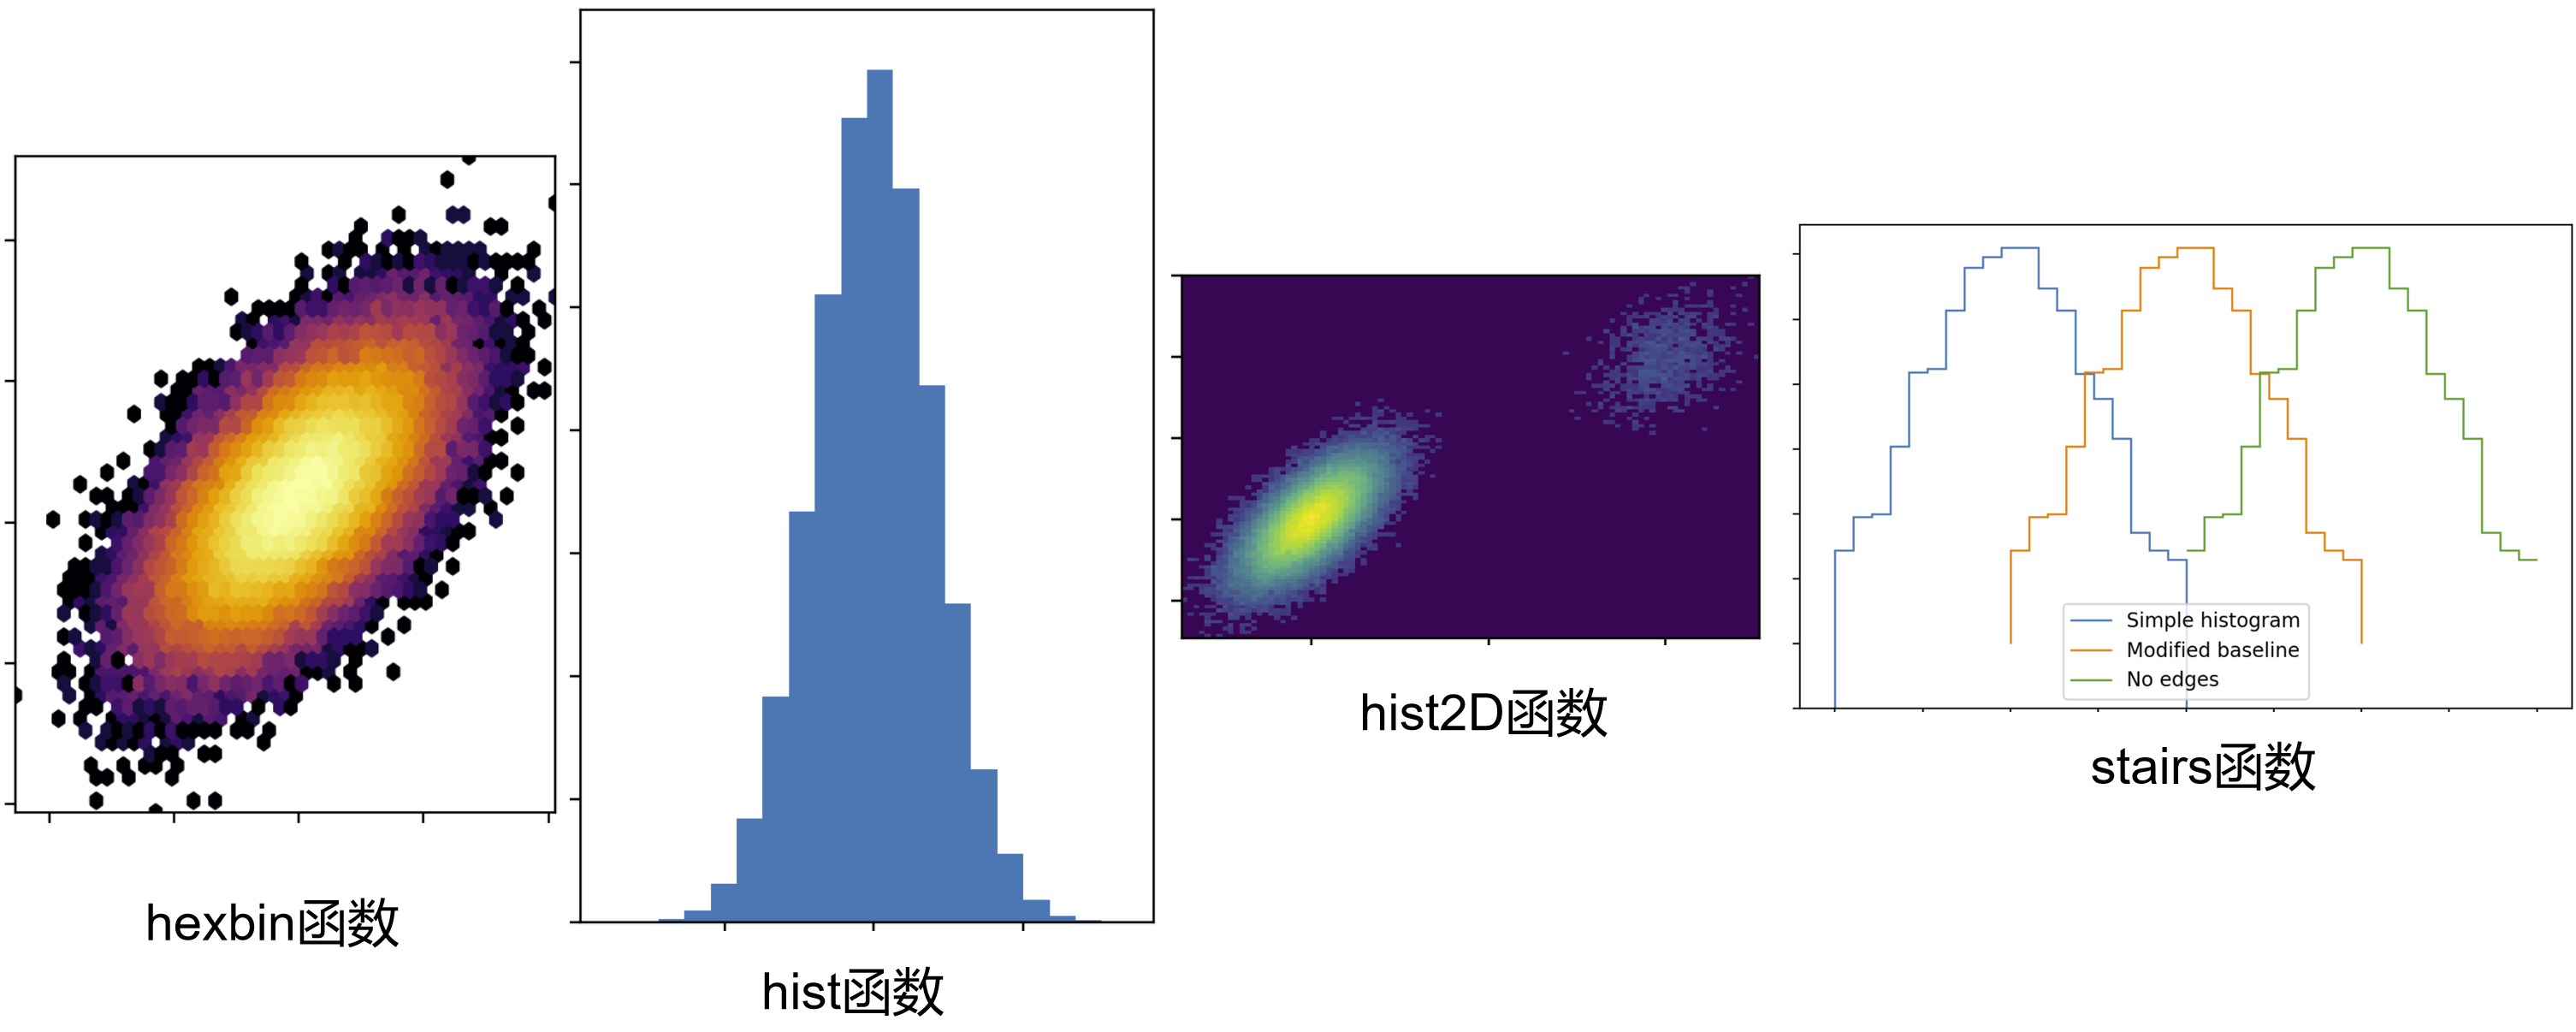

### (1) 直方图绘制-hist 

- hist函数负责绘制用于可视化单变量数据的分布情况。
    - 它将数据范围划分为一系列连续的、不重叠的区间（称为“箱子”或“bin”），然后统计每个区间内数据点的数量（频率）或比例（密度）。
    - 与violinplot函数绘制的密度分布的差异是：
        - hist函数采用的统计数据。
        - violinplot采用的是使用核函数的概率密度估计（一种无参估计）。

- 通过直方图可以进行如下数据分析：
    - 分析数据集的分布形状（例如，是否是正态分布、偏态分布）。
    - 分析数据的中心趋势和离散程度。
    - 分析异常值。

- hist函数的原型定义与参数说明：

```python
matplotlib.pyplot.hist(
    x,    # 绘制直方图需要的数据，参数类型是长度为n的数组或者序列。
    bins=None,  # 数据x的分组数，类型是int，序列或者字符串，bins使用多种当时指定分箱方式。
    *,  # 位置参数与关键字参数的分割符
    range=None, # 数据范围，超出范围的数据被忽略。类型是元组。
    density=False,  # 直方图的数据方式，True表示概率密度，False表示频率
    weights=None,  # 与x相同长度的权重系统。
    cumulative=False, # 绘制累积直方图，这个才x数据是向量数组的情况下有效，否则就是一个区间多个矩形。
    bottom=None, # 每个分箱的底线位置。
    histtype='bar', # 直方图的类型，可以取值{'bar', 'barstacked', 'step', 'stepfilled'}, 
    align='mid', # 直方图在水平方向在区间内的对齐方式，可以取值{'left', 'mid', 'right'}, 
    orientation='vertical',  # 直方图的方向
    rwidth=None,  # 每个矩形的箱规宽度，取值在[0,1]之间。
    log=False, # 直方图的坐标轴采用log对数刻度。
    color=None,  # 颜色样式
    label=None,  # 标签
    stacked=False,  # 多组数据的情况是否在用堆叠
    data=None, **kwargs  # 设置来自Patch对象的属性。
)
```

函数的返回3个值：(1)分箱的值n（频率与密度），数据是数组或者序列数组，取决于x的数据；（2）分箱的边界值bins。（3）绘制的每个Patch对象patchs

- 使用x参数
    - 该参数是必须参数
    - 该参数可以是是单个数组或多个数组的序列，序列中的每个数组长度可以不同。

[[  7.  26.  84. 223. 276. 212. 129.  34.   8.   0.   1.   0.   0.   0.
    0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   2.  20.  79.
  181. 270. 256. 133.  49.  10.]]
[-2.65394998 -2.29446906 -1.93498814 -1.57550723 -1.21602631 -0.85654539
 -0.49706448 -0.13758356  0.22189735  0.58137827  0.94085919  1.3003401
  1.65982102  2.01930194  2.37878285  2.73826377  3.09774469  3.4572256
  3.81670652  4.17618743  4.53566835]
<a list of 2 BarContainer objects>


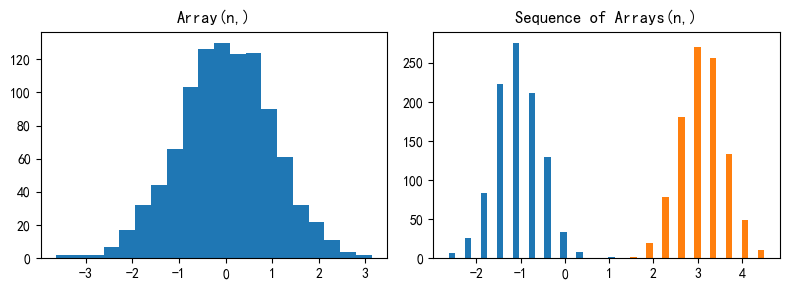

In [209]:
import matplotlib.pyplot as plt
import numpy as np

# 生成示例数据
data_array = np.random.normal(0, 1, 1000)  # 数组
data_sequence = [np.random.normal(-1, 0.5, 1000), np.random.normal(3, 0.5, 1000)]  # 数组序列

plt.figure(figsize=(8, 3))

plt.subplot(121)
plt.hist(data_array, bins=20)
plt.title("Array(n,)")

plt.subplot(122)
n, bins, patchs = plt.hist(data_sequence, bins=20)
print(n)
print(bins)
print(patchs)
plt.title("Sequence of Arrays(n,)")

plt.tight_layout()
plt.show()

- 代码说明：
    - 我们输出了hist函数的返回值，可以看见第一个返回值输出的是频率，而不是密度值，找个需要参数density设置。

- 使用bins参数
    - 指定直方图的分箱(bin)数量或边界，指定方式三种：
        - int类型：指定分箱数量，每个分箱是等宽。
        - 序列类型：指定分箱的边界值，其中的每个值即是上一个分箱的右边界，也是下一个分箱的左边界。最后分箱的个数是序列长度-1。
        - 字符串类型：指定分箱的算法，可以取如下值特定算法名称 ('auto', 'fd', 'doane', 'scott', 'stone', 'rice', 'sturges', 'sqrt')，这些算法可以自动计算出分箱的边界。这些分箱算法都是基于经验提出的算法，可以根据数据的实际情况选择。
    - bins的默认值可以使用环境参数`rcParams["hist.bins"]`设置。

- bins的分箱算法
    - 分箱算法的说明：
        - 如果分箱太少，直方图会过于粗糙，无法捕捉到数据分布的细节和形状，可能会掩盖重要的模式（如多峰性）。
        - 如果分箱太多，每个箱子里的数据点会非常少，直方图会变得“稀疏”和不稳定，受随机噪声的影响很大，呈现出许多不具代表性的波动。
        - 所以分箱算法(或者法则、规则)提供了一个随着数据量增加，而缓慢增加分箱数的简单方法。
    - sqrt法则：分箱数量$k = \sqrt{n}$，n是数据的数量或者长度。这是很多matplotlib，pandas的默认分箱法则。
    - 斯特奇斯（Sturges）法则：分箱数量$k = \log _2(n) + 1$
    - Freedman-Diaconis规则（fd法则）：该法则基于数据的散布和规模，分箱它的核心思想计算分箱宽度,分箱的宽度应该考虑数据的离散程度(通过四分位距 IQR 衡量) 和数据规模(n) ：
        - 计算公式是$w= 2 \times \dfrac{IQR}{\sqrt[3]{n}}$, 然后得到分箱数$k=\dfrac{数据范围}{w}$
    - Scott法则，该法则的核心思想是为直方图找到一个理论上最优的分箱宽度，这个宽度能够最小化直方图与真实的、未知的概率密度函数（PDF）之间的积分均方误差（MISE）。注：fd法则是最小化直方图与分布估计的误差，所以采用分布估计中的IQR值。
        - Scott法则做了一个关键假设：数据近似服从正态分布。在这个假设下，它推导出了一个计算全局固定分箱宽度的公式,分箱宽度$w = \dfrac{3.5 \times \delta}{\sqrt[3]{n}}$，$\delta$是数据样本的标准方差。
    - doane法则：该扩展Sturges法则以考虑数据偏度，计算公式：
        - 分箱数量$k = \log _2(n) + 1 + log _2(1 + \dfrac{|g1|}{\delta _ {g1}})$
        - 其中$g1$表示数据的样本偏度，$\delta _{g1}$表示样本偏度的标准方差。
        - $k$对计算结果向上取整。
    - Rice法则：该法则是一个非常直接的分箱数量计算方法，其核心思想是：分箱数量应该与数据量的立方根成正比。与Scott和Freedman-Diaconis法则不同，Rice法则不考虑数据的实际分布特征（如标准差、四分位距或偏度），它只依赖于一个变量——数据点的数量。
        - 分箱数量$k = 2 \times \sqrt[3]{n}$， k最后计算值如果不是整数，采用向上取整得到分箱数量。

- bins参数取值auto说明：
    - 首先，同时计算 'sturges' 和 'fd' 两种方法建议的分箱数量。
    - 然后，比较这两个结果。
    - 最终选择分箱数量较多的那个方法作为 'auto' 的结果。

- 使用bins参数的例子

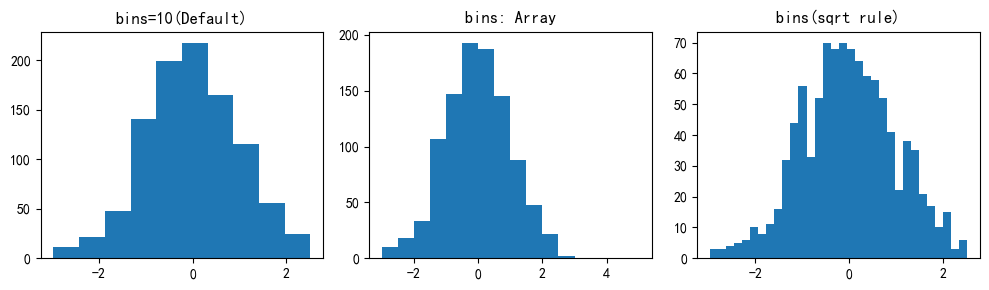

In [213]:
import matplotlib.pyplot as plt
import numpy as np

# 生成示例数据
x = np.random.normal(0, 1, 1000)  # 数组

plt.figure(figsize=(10, 3))
# bins是整数
plt.subplot(131)
plt.hist(x, bins=10)
plt.title("bins=10(Default)")

# bin是数组
plt.subplot(132)
plt.hist(x, bins=[-3, -2.5, -2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 5])
plt.title("bins: Array")

# bin是字符串表示的分箱算法
plt.subplot(133)
plt.hist(x, bins="sqrt")
plt.title("bins(sqrt rule)")

plt.tight_layout()
plt.show()


- 代码说明：
    - hist函数的bins参数的默认值是10。
    - bins使用的所有分箱规则产生的分箱数量，可以自行比较，总的来说每个分箱规则都有不同的考量，更多的是基于经验提出的算法。

- 影响直方图计算的几个参数：
    - x与bins参数，是直接影响直方图的计算数据，其实还有几个参数也与直方图计算相关：
        - range：指定处理的x数据的范围
        - density：指定计算的是频率还是密度，参数类型是bool，默认是False，表示计算的是频率，函数返回的也是频率（就是分箱区间出现的数据数量）
        - weights：指定x的权重，如果density=True，需要对权重进行标准化（归一化），确保密度的积分（和）为1。
        - cumulative：指定绘制累积直方图，参数为bool值或者-1，默认是False。取值为-1，表示方向累积。
            - 累积的效果就是后面一个bin是前面一个bin与当前bin的累加值，最后一个bin就是总频率或者1（概率密度的情况density=True的情况）

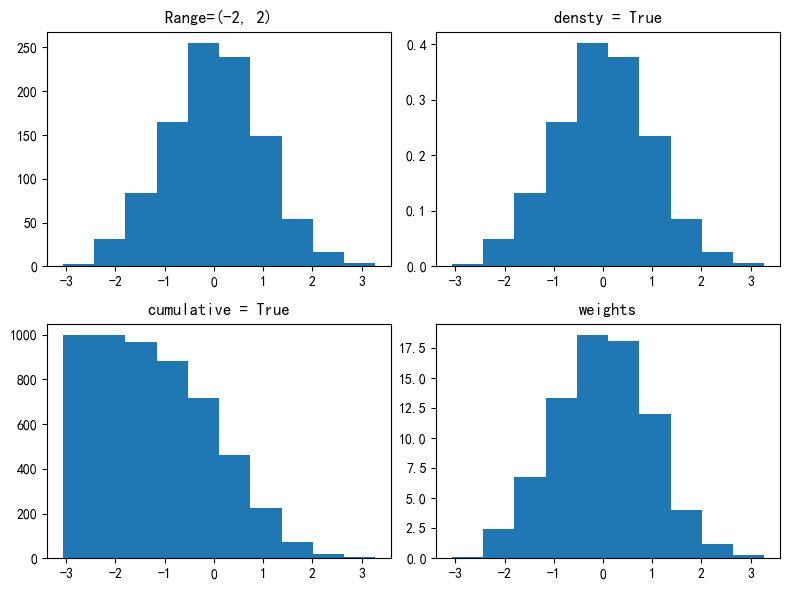

In [222]:
import matplotlib.pyplot as plt
import numpy as np

# 生成示例数据
x = np.random.normal(0, 1, 1000)  # 数组

plt.figure(figsize=(8, 6))
# bins是整数
plt.subplot(221)
plt.hist(x, bins=10)
plt.title("Range=(-2, 2)")

# bin是数组
plt.subplot(222)
plt.hist(x, density=True)
plt.title("densty = True")

# bin是字符串表示的分箱算法
plt.subplot(223)
plt.hist(x, cumulative=-1)   #  cumulative=True
plt.title("cumulative = True")

plt.subplot(224)
weights = np.abs(np.random.normal(0, 0.1, 1000))  # 使用权重强化中心点的数据重要性。我们去的方差是0.1, 我们取权重为整数

plt.hist(x, weights=weights) # density=True
plt.title("weights")

plt.tight_layout()
plt.show()


- 代码说明：
    - 设置density=True的时候，直方图的y坐标轴表示的是概率密度，其值在1范围内。如果density=False表示频率，其值是整数。
    - 我们对权重weights参数，需要注意的是对频率与密度的影响，从例子运行结果，这种影响还是比较大的。
    - cumulative=-1，是逆向累积（在density=True，第一个bin为1密度）。其实-1本身也是非零数，表示True。

- stacked与histtype参数对多数组序列数据的显示方式设置:
    - stacked参数是bool类型，默认值是False，表示不堆叠绘制。
    - histtype参数字符串，取值{'bar', 'barstacked', 'step', 'stepfilled'}, 默认是"bar"

- stacked参数使用例子：

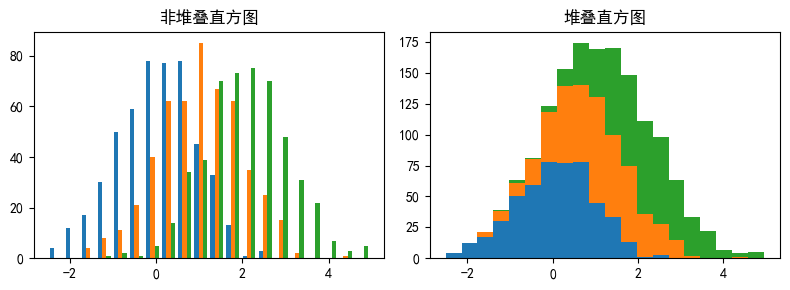

In [226]:
import matplotlib.pyplot as plt
import numpy as np

data_multi = [np.random.normal(i, 1, 500) for i in range(3)]

plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
plt.hist(data_multi, bins=20, stacked=False)
plt.title('非堆叠直方图')

plt.subplot(1, 2, 2)
plt.hist(data_multi, bins=20, stacked=True)
plt.title('堆叠直方图')

plt.tight_layout()
plt.show()


- 代码说明：
    - `data_multi = [np.random.normal(i, 1, 500) for i in range(3)]`代码生成三个向量组，三个向量组的中心位置分别为1,2,3。
    - 如果向量组的中心位置相隔太远会有什么效果？下面我们使用例子说明。

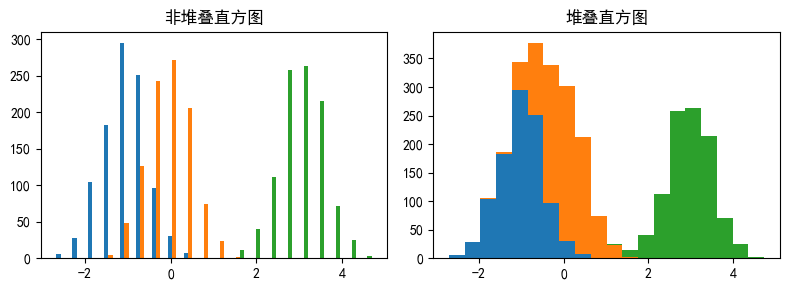

In [230]:
import matplotlib.pyplot as plt
import numpy as np

data_sequence = [np.random.normal(-1, 0.5, 1000), np.random.normal(0, 0.5, 1000), np.random.normal(3, 0.5, 1000)]  # 数组序列
plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
plt.hist(data_sequence, bins=20, stacked=False)
plt.title('非堆叠直方图')

plt.subplot(1, 2, 2)
plt.hist(data_sequence, bins=20, stacked=True)
plt.title('堆叠直方图')

plt.tight_layout()
plt.show()


- 代码说明：
    - stacked参数的使用需要在具有相邻很近的数据上使用效果会更好

- histtype参数使用例子：

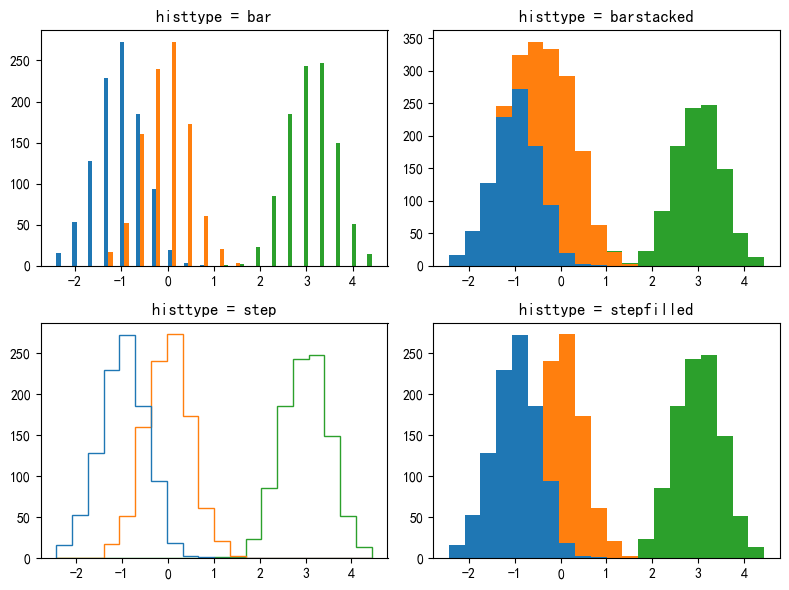

In [233]:
import matplotlib.pyplot as plt
import numpy as np

data_sequence = [np.random.normal(-1, 0.5, 1000), np.random.normal(0, 0.5, 1000), np.random.normal(3, 0.5, 1000)]  # 数组序列
plt.figure(figsize=(8, 6))

histtypes = ['bar', 'barstacked', 'step', 'stepfilled']
for i, ht in enumerate(histtypes, 1):
    plt.subplot(2, 2, i)
    plt.hist(data_sequence, bins=20, histtype=ht)
    plt.title(f'histtype = {ht}')

plt.tight_layout()
plt.show()

- 代码说明：
    - 在代码中采用了循环，分别展示了histtype的四种情况，从效果上来说histtype的效果与stacked，以及后面的stairs函数的效果一样。

- hist函数的其他样式修饰性参数的使用：
    - bottom：设置每个直方图的位置。使用一个float值指定所有分箱的下边位置, 默认值: 0，表示下面与x轴对齐。使用数组可以为每个分箱指定下边位置。
    - align：对直方图在x轴上区域的位置微调，取值{'left', 'mid', 'right'},默认值：'mid'。
    - orientation：设置直方图的方向，取值{'vertical', 'horizontal'}, 默认值: 'vertical'
    - rwidth：设置每个分箱宽度的系数，取值在0-1之间，如果取值None，则hist函数自动计算每个分箱宽度。
    - log：坐标轴采用对数刻度。参数类型是bool值，默认值是False。
    - color：设置分箱的颜色，如果是一个颜色值，则所有分箱采用这个颜色，也可以使用颜色数组，为数据的向量组的每个组指定一个颜色，如果为None（这是默认值），则使用标准的线性颜色循环。
    - label：设置标签。字符串（一个向量）或者字符串数组（向量序列）

- hist函数的样式修饰性参数使用例子:

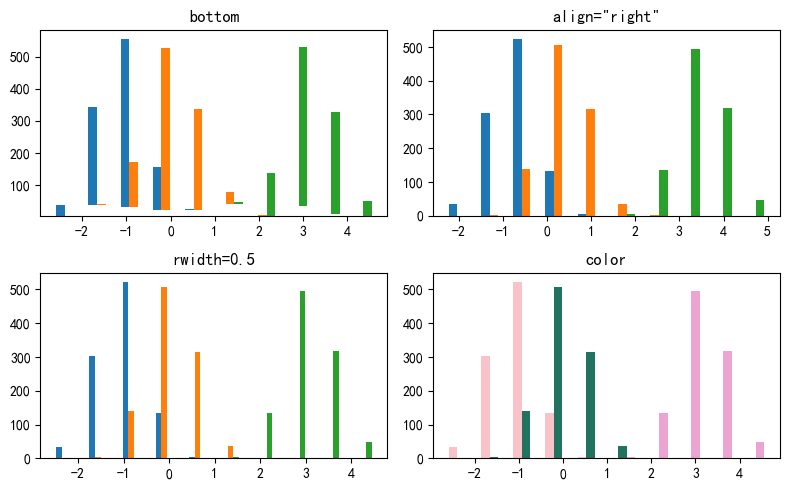

In [247]:
import matplotlib.pyplot as plt
import numpy as np
# 随机数生成器
generator = np.random.default_rng(seed=42)

data_sequence = [np.random.normal(-1, 0.5, 1000), np.random.normal(0, 0.5, 1000), np.random.normal(3, 0.5, 1000)]  # 数组序列
plt.figure(figsize=(8, 5))
bins = 10

# 随机生成与bins数量一样的数组，用来设置每个分箱的下边位置。
plt.subplot(221)
bottom = generator.integers(0, 50, size=bins)  # 生成0到50之间的随机整数
plt.hist(data_sequence, bins=bins, bottom=bottom)
plt.title('bottom')

plt.subplot(222)
plt.hist(data_sequence, bins=bins, align="right")
plt.title('align="right"')

plt.subplot(223)
plt.hist(data_sequence, bins=bins, rwidth=0.5)
plt.title('rwidth=0.5')

plt.subplot(224)
color = generator.random(size=(len(data_sequence), 3)) # 生成随机三原色，需要使用0-1之间的小数作为颜色分量
plt.hist(data_sequence, bins=bins, color=color)
plt.title('color')

plt.tight_layout()
plt.show()

- 代码说明：
    - `color = generator.random(size=(len(data_sequence), 3))`生成颜色，这里需要注意的是二维颜色数组，其中每行表示一个颜色，采用这种格式的颜色，其分量必须是0-1之间的小数。而且这个颜色不是与分箱数量一致，而是与数据x中的向量组的组数一致，我们使用了三组数据，所以指定颜色也是三个。

- 参数log的使用
    - 在坐标轴中引入对数刻度，是为了更好可视化一些指数级变化的数据，这样数据可以更好的展示。尤其是长尾分布的数据。
    - 我们下面在例子中，顺便使用Patch对象的属性来设置hist函数的参数。

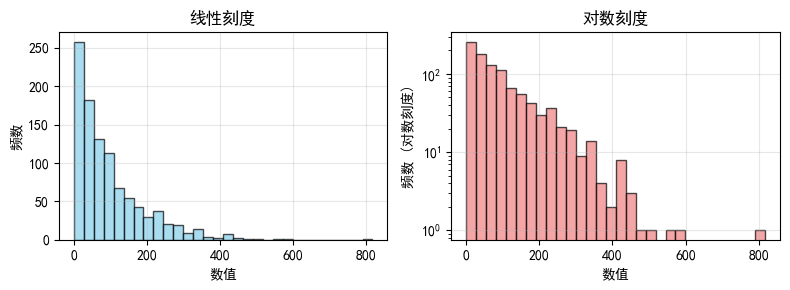

In [249]:
import matplotlib.pyplot as plt
import numpy as np

# 生成示例数据 - 包含较大范围的值
np.random.seed(42)
data = np.random.exponential(scale=100, size=1000)  # 指数分布数据

plt.figure(figsize=(8, 3))

# 线性刻度
plt.subplot(1, 2, 1)
plt.hist(data, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('线性刻度')
plt.xlabel('数值')
plt.ylabel('频数')
plt.grid(True, alpha=0.3)

# 对数刻度
plt.subplot(1, 2, 2)
plt.hist(data, bins=30, alpha=0.7, color='lightcoral', edgecolor='black', log=True)
plt.title('对数刻度')
plt.xlabel('数值')
plt.ylabel('频数 (对数刻度)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- 代码说明：
    - 注意上面例子中，y轴采用了log对数刻度。使用log刻度，直方图的分布具有线性规律。
    - 尤其是一些长尾数据，采用log刻度可以具有更好的可视化效果。下面例子就是说明log刻度的作用。

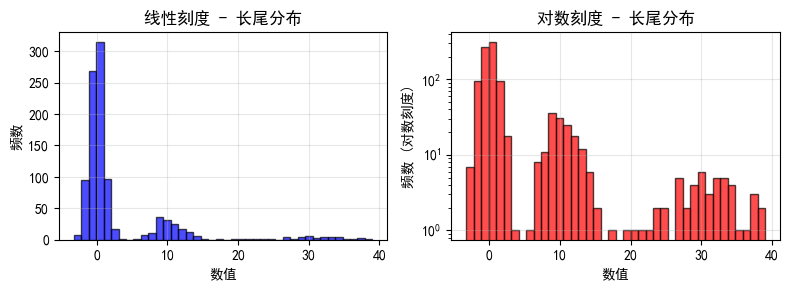

In [252]:
import matplotlib.pyplot as plt
import numpy as np
# 生成长尾分布数据
np.random.seed(42)
data_long_tail = np.concatenate([
    np.random.normal(0, 1, 800),      # 大部分数据在0附近
    np.random.normal(10, 2, 150),     # 一些中等值
    np.random.normal(30, 5, 50)       # 少数大值
])

plt.figure(figsize=(8, 3))

# 线性刻度 - 难以看清细节
plt.subplot(1, 2, 1)
counts, bins, patches = plt.hist(data_long_tail, bins=40, 
                                alpha=0.7, color='blue', edgecolor='black')
plt.title('线性刻度 - 长尾分布')
plt.xlabel('数值')
plt.ylabel('频数')
plt.grid(True, alpha=0.3)

# 对数刻度 - 更好地显示所有区间
plt.subplot(1, 2, 2)
counts, bins, patches = plt.hist(data_long_tail, bins=40, 
                                alpha=0.7, color='red', edgecolor='black', log=True)
plt.title('对数刻度 - 长尾分布')
plt.xlabel('数值')
plt.ylabel('频数 (对数刻度)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### (2) 阶梯图绘制-stairs

- stairs函数负责绘制阶梯图，特别适用于可视化离散数据的分布，如直方图数据。
    - stairs函数是直接对数据进行阶梯展示，不对数据进行统计处理。

- stairs函数的原型定义与参数说明

```python
matplotlib.pyplot.stairs(
    values,    # x参数是一个数组，设置每个阶梯高度
    edges=None,  # 阶梯位置，参数的长度应该比values的长度多1，len(edges) == len(vals) + 1，用来设置阶梯的宽度。
    *, 
    orientation='vertical', 
    baseline=0,  # baseline参数用于控制阶梯图的基线位置和样式，对形成封闭图形的边界，与填充情况下的边界。
    fill=False,  # 设置是否填充阶梯, 默认值False；不填充, 填充阶梯下面区域
    data=None, 
    **kwargs)  # 设置来自StepPatch对象的属性。
```

- stairs函数的values与edges参数的使用例子：
    - 注意hist中统计后的频率也是离散数据。values直接设置每个阶梯的高度。
    - values参数是必须的，edges参数可选。
    - edges参数为None的情况会制动采用range(0, len(values)+1)

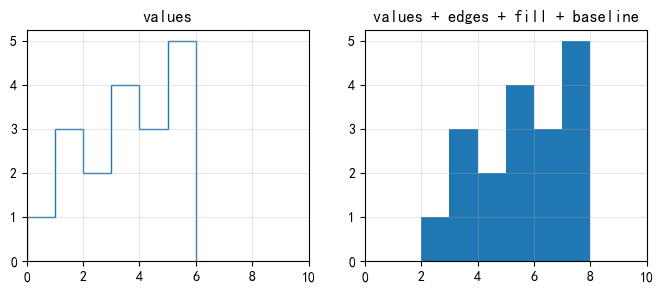

In [260]:
import matplotlib.pyplot as plt
import numpy as np

# 示例数据
values = [1, 3, 2, 4, 3, 5]

plt.figure(figsize=(8, 3))

# 基本 stairs 绘图
plt.subplot(121)
plt.stairs(values)   # edges 的默认值： [0, 1, 2, 3, 4, 5, 6]  # 边界值
plt.xlim(0, 10)
plt.title('values')
plt.grid(True, alpha=0.3)

plt.subplot(122)
edges = [2, 3, 4, 5, 6, 7, 8]  # 边界值
plt.stairs(values, edges, fill=True)
plt.xlim(0, 10)
plt.title('values + edges + fill')
plt.grid(True, alpha=0.3)


plt.show()

- baseline参数的说明与使用
    - baseline是标量（float类型）: 每个阶梯一样的基线值
    - baseline是数组: 设置每个阶梯的基线。
    - bseline设置为None：绘制不封闭的图形，因为没有基线,所以fill不能设置为True。
    - 注意：基线不会改变阶梯的位置。

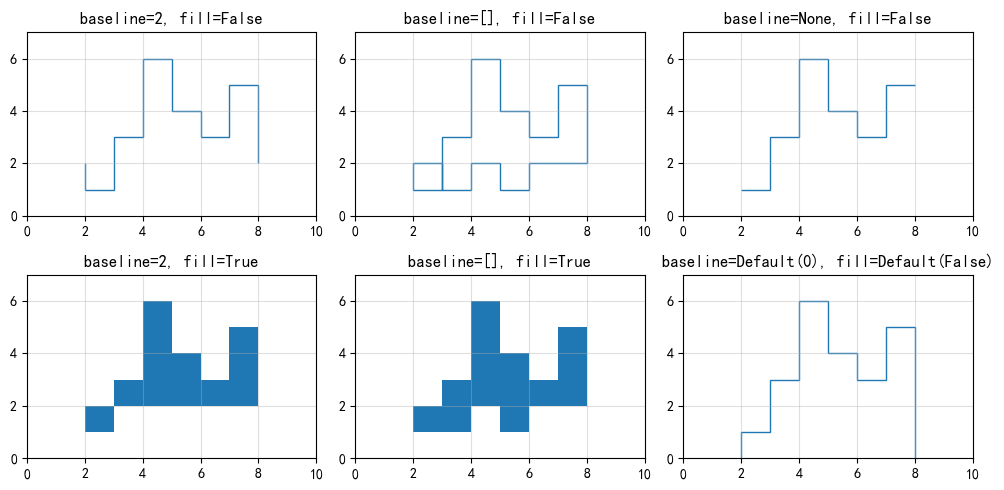

In [275]:
import matplotlib.pyplot as plt
import numpy as np

# 示例数据
values = [1, 3, 6, 4, 3, 5]
edges =  [2, 3, 4, 5, 6, 7, 8]
plt.figure(figsize=(10, 5))

# 基本 stairs 绘图
plt.subplot(231)
plt.stairs(values, edges=edges, baseline=2, fill=False)
plt.xlim(0, 10)
plt.ylim(0, 7)
plt.title('baseline=2, fill=False')
plt.grid(True, alpha=0.4)


plt.subplot(232)
plt.stairs(values, edges=edges, baseline=[2, 1, 2, 1, 2, 2], fill=False)
plt.xlim(0, 10)
plt.ylim(0, 7)
plt.title('baseline=[], fill=False')
plt.grid(True, alpha=0.4)

plt.subplot(233)
plt.stairs(values, edges=edges, baseline=None, fill=False)
plt.xlim(0, 10)
plt.ylim(0, 7)
plt.title('baseline=None, fill=False')
plt.grid(True, alpha=0.4)

plt.subplot(234)
plt.stairs(values, edges=edges, baseline=2, fill=True)
plt.xlim(0, 10)
plt.ylim(0, 7)
plt.title('baseline=2, fill=True')
plt.grid(True, alpha=0.4)

plt.subplot(235)
plt.stairs(values, edges=edges, baseline=[2, 1, 2, 1, 2, 2], fill=True)
plt.xlim(0, 10)
plt.ylim(0, 7)
plt.title('baseline=[], fill=True')
plt.grid(True, alpha=0.4)

plt.subplot(236)
# plt.stairs(values, edges=edges, baseline=None, fill=True) # baseline=None的时候，fill不能为True
plt.stairs(values, edges=edges)
plt.xlim(0, 10)
plt.ylim(0, 7)
plt.title('baseline=Default(0), fill=Default(False)')
plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

- 代码说明：
    - 第一个图表：baseline决定了阶梯开始绘制的位置，第一个阶梯从baseline=2开始绘制，最后一个阶梯在baseline结束。
    - 第二个图表：每个阶梯都对应一个baseline（baseline是与values同长的数组），则绘制封闭阶梯图。
    - 第三个图表：当baseline=None，绘制的阶梯图不会封闭，这个时候fill只能是False。
    - 第四个图表：所有阶梯使用一样的基线，填充只填充阶梯值与baseline基线之间的区域。如果values值小于基线，这填充区域在基线下，如果values大于基线，则填充区域在基线上。
    - 第五个图表：每个阶梯的基线不同，但是填充规则与图表四一样。
    - 第五个图表
    - ；全部采用默认值，用来参考对比每个参数对阶梯图的影响。

### (3) 二维热力图绘制-hist2d

- hist2d负责绘制二维直方图（热力图），它可以显示两个变量之间的分布关系。重点理解两个变量的分布与分布关系。
- hist2d与hist都是绘制直方图，所以很多参数的近似，
    - hist函数是在2D平面上绘制一个变量的分布，
    - hist2d函数是在3D平面绘制两个变量的分布关系，需要注意的是这里的三维不是我们传统意义上的物理3维空间，而是采用了颜色来表示第三位的值。也就是密度分布的值使用颜色表示。不同颜色表示不同的概率密度。

- hist2d函数的原型定义与参数说明:

```python
matplotlib.pyplot.hist2d(
    x, y,  # 两个长度为n的一维向量
    bins=10,  # 分箱数，参数形式可以为：（1）None表示默认值10，（2）int整数，指定x，y的分箱数，（3）(int, int)分别制定x，y的分箱数。（4）(数组，数组)分别指定x，y的分箱边界区域。规则与hist函数一致。hist2d函数没有使用字符串指定分箱规则。
    *, 
    range=None,  # 指定x，y数据样本的范围，范围外的数据忽略。参数形式为：[[xmin, xmax], [ymin, ymax]]
    density=False, # 设置统计数据是概率密度还是频率。
    weights=None,  # 为x，y指定加权系数，长度与x，y一致，其中(xi, yi)共享wi权重。
    cmin=None,  # 颜色的最小值，统计结果小于cmin的数据不会显示。
    cmax=None,  # 颜色的最大值，统计结果大于cmax的数据不会显示。
    data=None, 
    **kwargs) # 设置来自QuadMesh对象的属性，以及来自函数pcolormesh的参数，以及其他参数（以官方文档为准）
```
函数返回4个值：（1）h: 直方图计数的 2D 数组；（2）xedges, yedges: 箱边界；（3）image: QuadMesh 对象

- 使用二维数据拉分析其分布状态的例子
    - 例子中，我们使用了x，y参数与bins参数

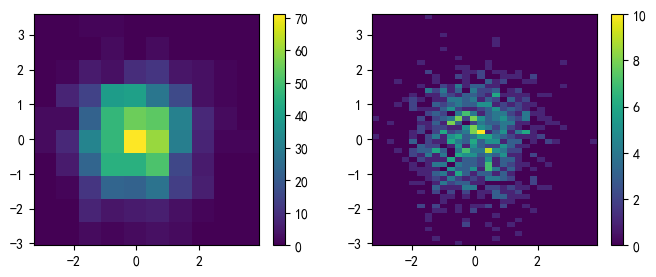

In [287]:
import matplotlib.pyplot as plt
import numpy as np

# 生成示例数据
x = np.random.normal(0, 1, 1000)
y = np.random.normal(0, 1, 1000)

plt.figure(figsize=(8, 3))

plt.subplot(121)
# 基本二维直方图
plt.hist2d(x, y)
plt.colorbar()  # 添加颜色条

plt.subplot(122)
plt.hist2d(x, y, bins=[30, 50])
plt.colorbar()  # 添加颜色条

plt.show()

- 代码说明：
    - x，y必须是一样长度的向量。x, y分箱后，在二维平面中就是正方形格子，统计的是x与y对应形成的二维坐标点在格子中的数量。根据颜色，可以看出那个格子中的$(x_i, y_i)$点最多。在二维平面中就是曲线，最多的就是峰值。
    - bins在hist2d函数中不支持分箱规则算法，也就是不支持使用"scott"，"fd"，"sqrt"等分箱算法字符串。
    - x，y必须一样的原因是，统计的是平面中的点，点使用二维坐标表示$(x_i, y_i)$, 其实只是把点的坐标表示分开使用x向量与y向量作为输入数据，如果不一样长，某个向量中就多出分量，hist2d不允许这种情况出现，如果不一样，hist2d函数会抛出异常。

- 与hist函数类似的几个参数不再重复介绍
    - range参数：指定坐标的范围，范围外的数据被忽略。
    - density参数：使用逻辑设置计算频率还是计算概率密度。
    - weights参数：这个权重是与二维点对应的，也就是也与x有的长度保持一致。

- hist2d函数中的颜色映射，与颜色映射相关的参数有：
    - camp参数：设置映射的颜色。
    - cmax、cmin参数：设置颜色的范围，超过范围的数据不显示颜色。
    - norm参数：设置数据标准的方法，参数可以是Normalize对象，或者一些内置标准化对象，使用字符串指定，一般有 "linear", "log", "symlog", "logit"等。一般把值映射为颜色之前，需要对值进行标准化处理（就是处理为0-1之间的值），然后在映射到某个颜色，并使用颜色填充区间格子。
    - 与norm参数一样作用的还有vmin, vmax参数，一般norm与vmin, vmax参数不能同时使用（除非norm使用字符串指定标准化内置对象，而且norm优先，norm指定字符串的算法可能会使用vmin与vmax参数的值）。
    - colorizer参数：指定数据映射到颜色的处理。参数是Colorizer对象，或者None，如果为None，则使用norm与cmap完成颜色映射。
    - alpha参数：指定颜色的透明度设置，其值在0-1之间的float值。
    - 注意：上述参数我们在讲解Colorbar对象的时候也说明过，而且后面我们还有专门的颜色主题。我们这里仅仅使用一个例子说明即可。

- hist2d函数使用颜色相关参数设置颜色映射的例子

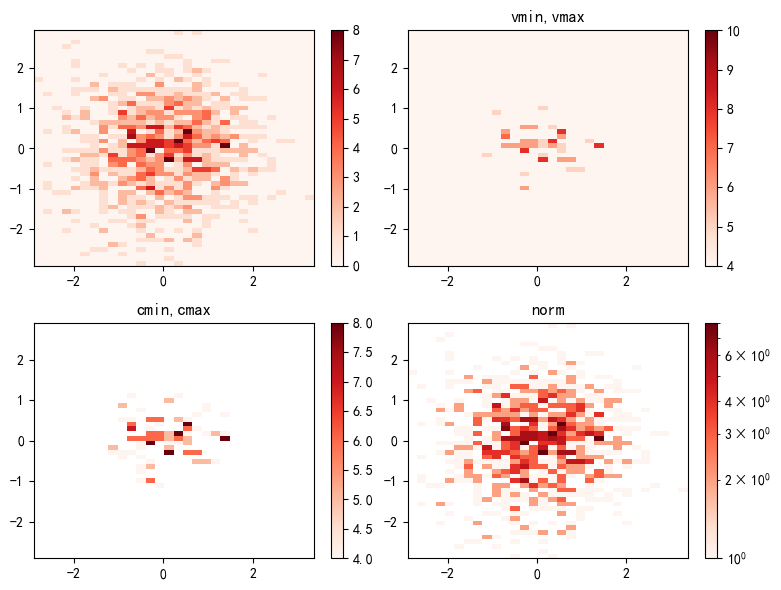

In [298]:
import matplotlib.pyplot as plt
import numpy as np

# 生成示例数据
x = np.random.normal(0, 1, 1000)
y = np.random.normal(0, 1, 1000)

plt.figure(figsize=(8, 6))

plt.subplot(221)
plt.hist2d(x, y, bins=[30, 50], cmap="Reds")
plt.colorbar()  # 添加颜色条

plt.subplot(222)
plt.hist2d(x, y, bins=[30, 50], cmap="Reds", vmin=4, vmax=10)
plt.colorbar()  # 添加颜色条
plt.title("vmin,vmax")

plt.subplot(223)
plt.hist2d(x, y, bins=[30, 50], cmap="Reds", cmin=4, cmax=10)
plt.colorbar()  # 添加颜色条
plt.title("cmin,cmax")

plt.subplot(224)
plt.hist2d(x, y, bins=[30, 50], cmap="Reds", norm="log")
plt.colorbar()  # 添加颜色条
plt.title("norm")

plt.tight_layout()
plt.show()

- 代码说明：
    - vmin,vmax可以过滤不想显示的数据。作用类似cmin与cmax

### (4) 六边形图绘制-hexbin

- hexbin函数负责六边形分箱统计数据绘制，是一种用于可视化二维数值数据分布的方法，特别适用于处理大规模数据集。它将二维平面划分为六边形网格，并统计每个六边形内的数据点数量，然后根据数量进行着色。作用与hist，hist2d类似，知识表示方式不同，都用来分析数据的概率密度分布。
    - hist2d与hexbin对二维平面中的数据点进行分箱统计，hist对一维数据进行分箱统计。

- hexbin函数的原型定义与参数说明：

```python
matplotlib.pyplot.hexbin(
    x, y,   # 需要进行分析的数据，x，y是长度一样的向量或者数组，x，y一起构成与x，y一样多的点(xi, yi), xi∈x , yi∈y%
    C=None, # 与x，y一样长的向量或者数组，用来做统计累积的初始值。
    *, 
    gridsize=100,   # 指定六边形的个数，参数格式是int，表示x方向的六边形个数，y方向的六边形数量根据六边形绘制的布局计算，一般是x方向的3的立方根倍。
    bins=None, # 对统计的数据进行分箱，并映射到颜色，找个参数决定了颜色的数量与精确度。 
    xscale='linear',   # x轴的缩放处理方式
    yscale='linear',   # y轴的缩放处理方式
    extent=None,   # 一个四元数，用来限制分箱的范围，数据格式是(xmin, xmax, ymin, ymax)
    cmap=None,  # 指定需要映射的颜色映射。
    norm=None,  # 颜色映射前的标准化处理方式（是vmin，vmax的对象封装方式）
    vmin=None,  # 颜色映射前的标准化处理方式（线性标准化）- 标准化范围最小值
    vmax=None,  # 颜色映射前的标准化处理方式（线性标准化）- 标准化范围最大值
    alpha=None,   # 六边形上色的透明度
    linewidths=None,  # 六边形的线宽
    edgecolors='face',  # 六边形的边线颜色
    reduce_C_function=<function mean>,   # 处理参数C的累积方式，参数类型是一个函数对象。
    mincnt=None,  # 设置六边形单元显示的阈值，小于参数值的六边形不显示。
    marginals=False,  # 设置边缘密度的绘制方式，边缘密度绘制为沿x轴底部和y轴左侧的颜色映射矩形。
    colorizer=None,  # 设置颜色映射方式
    data=None, 
    **kwargs)  # 设置来自PolyCollection对象的属性。
```

函数的返回值：（1）PolyCollection 对象（2）通过PolyCollection对象得到相关统计数据：PolyCollection.get_offsets得到落在六边形中的点坐标，格式是(M,2)形状的矩阵，一行一个坐标点。PolyCollection.get_array得到统计值。

- 理解gridsize与bins参数：
    - bins参数对统计值分箱，然后映射到颜色，会产生不同的色阶。
        - 字符串类型: 'log'表示使用对数来进行统计值分箱:$\log _{10}(i+1)$，等价于参数norm设置为`norm=LogNorm()`
        - int类型: 对所有六边形的统计值进行分箱，参数指定了分箱的数量，每个分箱数量对应一个颜色。
        - 序列或者数组类型：设置统计值的边界区域，每个区域的值映射到一个颜色。
        - 默认值: None，表示每个六边形的数据点统计数量直接映射到颜色。
    - gridsize设置六边形在x，y轴方向的个数。
        - int类型： 设置x方向六边形个数，y方向根据规则原则（x，y方向整体大小近似）自动计算，一般y方向的六边形个数满足$x_n = \sqrt{3}n_y$，$n_x$表示x方向六边形个数。根据六边形的绘制方式，一般x方向的gridsize要大点。
        - (int, int)类型：设置x与y方向六边形个数。
        - 默认值是100. 

- gridsize与bins参数的作用与区别体验例子：

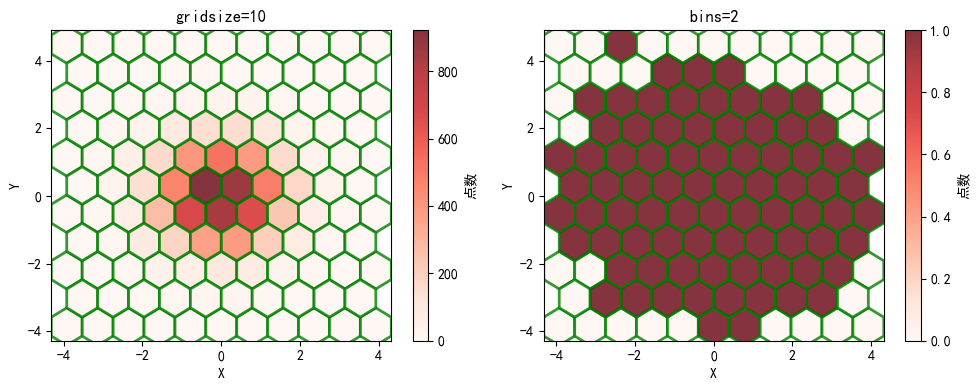

In [309]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False   # 用来正常显示负号

# 生成示例数据
np.random.seed(42)
x = np.random.normal(0, 1, 10000)
y = np.random.normal(0, 1, 10000)

# 创建 hexbin 图
plt.figure(figsize=(10, 4))

plt.subplot(121)
hb = plt.hexbin(x, y, gridsize=10, cmap='Reds', alpha=0.8, linewidths=2, edgecolor="green")
plt.colorbar(hb, label='点数')
plt.title('gridsize=10')
plt.xlabel('X')
plt.ylabel('Y')

plt.subplot(122)
hb = plt.hexbin(x, y, gridsize=10, cmap='Reds', bins=2, alpha=0.8, linewidths=2, edgecolor="green")
plt.colorbar(hb, label='点数')
plt.title('bins=2')
plt.xlabel('X')
plt.ylabel('Y')

plt.tight_layout()
plt.show()

- 代码说明：
    - 代码`hb = plt.hexbin(x, y, gridsize=10, cmap='Reds', alpha=0.8, linewidths=2, edgecolor="green")`中gridsize=10，这是是x方向六边形的个数，x方向的六边形个数每行不同，一行为10，一行是11。我们以少的为准。
    - 代码`hb = plt.hexbin(x, y, gridsize=10, cmap='Reds', bins=2, alpha=0.8, linewidths=2, edgecolor="green")`中bins=2，等于把色阶分成2个。
    - 在上面代码中为了更好观察六边形，我们设置了六边形的样式参数:`linewidths=2, edgecolor="green"`

- 理解与使用C参数的例子：
    - 与C参数有关的参数是reduce_C_function，用来处理C的累积，默认是numpy中的mean函数，做平均值。还可以是：
        - numpy.sum：求和
        - numpy.mean：均值
        - numpy.amax：取最大值
    - C参数的类型是一个与x，y一样长的数组或者序列。
    - 参数reduce_C_function的函数原型满足`def reduce_C_function(C: array) -> float`

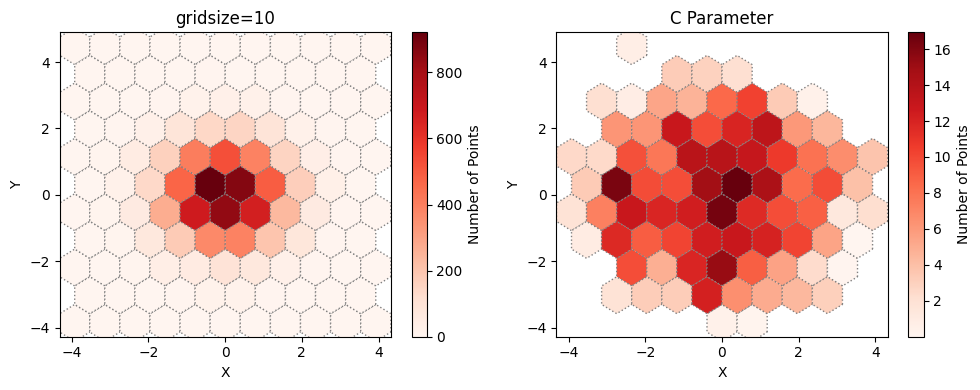

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def reduce_C_function(C) -> float:
    # return np.sum(C)
    # return np.mean(C)
    return np.amax(C)

# 生成示例数据
np.random.seed(42)
x = np.random.normal(0, 1, 10000)
y = np.random.normal(0, 1, 10000)

# 创建 hexbin 图
plt.figure(figsize=(10, 4))

plt.subplot(121)
hb = plt.hexbin(x, y, gridsize=10, cmap='Reds',linewidths=1, linestyle=':', edgecolor="gray")
plt.colorbar(hb, label='Number of Points')
plt.title('gridsize=10')
plt.xlabel('X')
plt.ylabel('Y')

plt.subplot(122)
C = np.random.exponential(2, 10000) # β=2，是指数分布的均值
hb = plt.hexbin(x, y, C=C, reduce_C_function=reduce_C_function, gridsize=10, cmap='Reds', linewidths=1, linestyle=':', edgecolor="gray")
plt.colorbar(hb, label='Number of Points')
plt.title('C Parameter')
plt.xlabel('X')
plt.ylabel('Y')

plt.tight_layout()
plt.show()

- 代码说明：
    - C参数的价值就是：不再使用在六边形中的点数统计来绘制颜色，而是使用C参数中对应位置落在六边形中的值最终聚合的结果来绘制颜色。这样做可以使用更加有意义的数据来替代原来的点数统计数据来绘制颜色。比如原来六边形统计的数环境观察点数量，C是每个观察点观察的环境污染指数，如果使用C后，在图表绘制的不在仅仅是管观察点数量，而是污染指数。
    - reduce_C_function函数的参数是落在六边形内的点的位置对应的C的值，函数中可以对落在该六边形内的C的值进行聚合处理，处理结果返回给hexbin，然后映射到颜色进行绘制。其中聚合处理方式可以根据实际情况处理，提供这个函数的目的是提供更加定制化的处理，常见的处理可以使用numpy中的常规聚合处理：
        - numpy.mean
        - numpy.max
        - numpy.min
        - numpy.sum
        - numpy.std

- 使用hexbin来分析环境污染指数的例子：

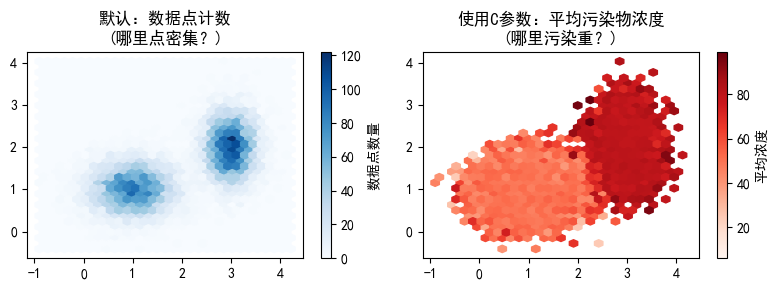

In [13]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False   # 用来正常显示负号

# 生成示例数据
np.random.seed(123)
n_points = 10000

# 数据点位置：集中在两个区域
x = np.concatenate([np.random.normal(1, 0.5, n_points//2),
                    np.random.normal(3, 0.3, n_points//2)])
y = np.concatenate([np.random.normal(1, 0.4, n_points//2),
                    np.random.normal(2, 0.5, n_points//2)])

# C参数：每个数据点对应的污染物浓度
# 假设两个区域的污染水平不同
concentration = np.concatenate([np.random.normal(50, 15, n_points//2),  # 第一个区域，平均浓度50
                                np.random.normal(80, 10, n_points//2)]) # 第二个区域，平均浓度80

# 创建一个画布，对比两种绘图方式
plt.figure(figsize=(8, 3))

# 1. 不使用C参数：默认计数
plt.subplot(121)
hex1 = plt.hexbin(x, y, gridsize=30, cmap='Blues')
plt.title('默认：数据点计数\n(哪里点密集？)')
plt.colorbar(hex1, label='数据点数量')

# 2. 使用C参数：显示平均浓度
plt.subplot(122)
hex2 = plt.hexbin(x, y, C=concentration, gridsize=30, cmap='Reds')
plt.title('使用C参数：平均污染物浓度\n(哪里污染重？)')
plt.colorbar(hex2, label='平均浓度')

plt.tight_layout()
plt.show()

- xscale，yscale参数的理解与使用
    - xscale，yscale参数主要设置来调整x，y轴的缩放。x,y轴的缩放其实也是数据点缩放，这种缩放也控制着数据在图表上的分布方式，这种情况在指数级数据的可视化有特别明显的效果。
    - xscale，yscale参数取值{'linear', 'log'}, 默认值是：'linear'
        - 'linear'：常规的标准坐标系刻度。
        - 'log'：最常用的非线性尺度，适用于数据跨越多个数量级的情况，每个数量级占据相同的物理距离，能够同时显示很小和很大的值，指数关系在图上表现为线性关系。

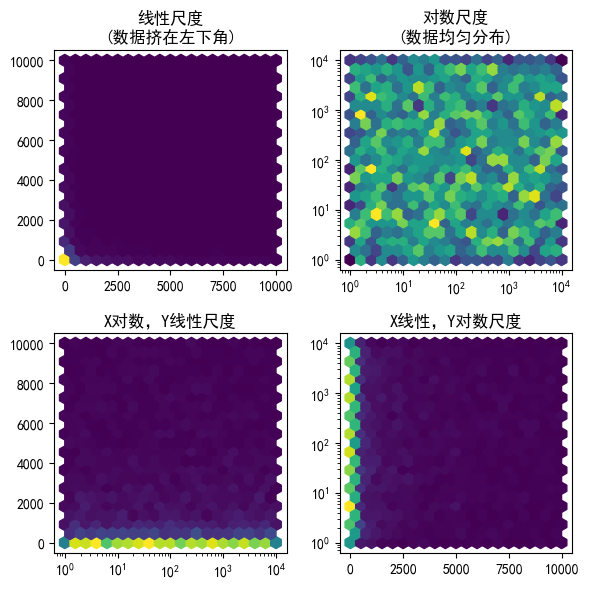

In [18]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False   # 用来正常显示负号

# 专门展示对数尺度的优势
plt.figure(figsize=(6, 6))

# 数据跨越多个数量级
x_log = 10 ** np.random.uniform(0, 4, 5000)  # 从10^0到10^4（均匀分布）
y_log = 10 ** np.random.uniform(0, 4, 5000)

# 线性尺度 - 数据挤在左下角
plt.subplot(221)
hex_lin = plt.hexbin(x_log, y_log, gridsize=20, xscale='linear', yscale='linear')
plt.title('线性尺度\n(数据挤在左下角)')
plt.colorbar(hex_lin, ax=axes[0, 0])

# 对数尺度 - 数据均匀分布
plt.subplot(222)
hex_log = plt.hexbin(x_log, y_log, gridsize=20, xscale='log', yscale='log')
plt.title('对数尺度\n(数据均匀分布)')
plt.colorbar(hex_log, ax=axes[0, 1])

# 混合尺度
plt.subplot(223)
hex_mixed = plt.hexbin(x_log, y_log, gridsize=20, xscale='log', yscale='linear')
plt.title('X对数，Y线性尺度')
plt.colorbar(hex_mixed, ax=axes[1, 0])

# 另一个混合尺度
plt.subplot(224)
hex_mixed2 = plt.hexbin(x_log, y_log, gridsize=20, xscale='linear', yscale='log')
plt.title('X线性，Y对数尺度')
plt.colorbar(hex_mixed2, ax=axes[1, 1])

plt.tight_layout()
plt.show()

- 代码说明：
    - `x_log = 10 ** np.random.uniform(0, 4, 5000)`代码使用指数运算生成5000个数据，生成的数据呈指数分布，在gridsize=20的设置下，因为数据的指数分布，在相同宽度的区域内，越到后面的区域数据统计点越少。
        - `xscale='linear', yscale='linear'`：因为采用标准坐标系刻度，而且数据是指数增长，所以从颜色上观察，数据都集中分布在左下角。
        - `xscale='log', yscale='log'`：因为x，y轴都采用log刻度，所以数据呈均匀分布。
        - `xscale='log', yscale='linear'`：因为x采用log刻度，y采用标准坐标刻度，所以数据集中在下边。
        - `xscale='linear', yscale='log'`：因为x采用标准坐标刻度，x采用log坐标刻度，所以数据集中在左边。
    - 其实为了更好的显示数据，坐标轴刻度还可以使用。
        - 'symlog'：这种坐标轴刻度在零附近使用线性尺度，在远离零的区域使用对数尺度
        - 'logit'： 适用于数据集中在0和1附近的情况，比如概率、比例等。这种情况与log是相对的，对小数据可以更加友好。

- 使用参数mincnt与extent
    - mincnt参数设置六边形显示的最小数据点数量阈值，只有包含数据点数量 ≥ mincnt 的六边形才会被显示和着色。可以过滤稀疏数据，突出密集区域，避免显示统计上不可靠的少量数据点，使图形更清晰。
    - extent明确指定绘图的数据范围，格式为 (xmin, xmax, ymin, ymax)。该参数可以限制绘图区域，排除边缘的异常值，确保多个图形有相同的坐标范围，便于比较，

- mincnt参数的使用例子

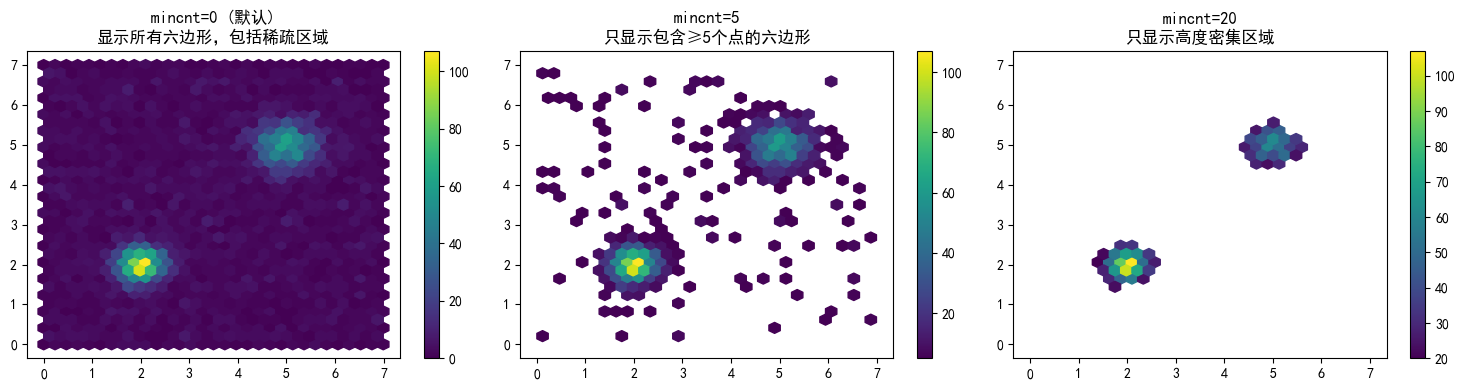

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False   # 用来正常显示负号

# 生成示例数据：两个密集区域 + 稀疏背景
np.random.seed(42)
n_points = 5000

# 两个密集区域
x_dense1 = np.random.normal(2, 0.3, n_points//4)   # 方差小，数据集中
y_dense1 = np.random.normal(2, 0.3, n_points//4)

x_dense2 = np.random.normal(5, 0.4, n_points//4)
y_dense2 = np.random.normal(5, 0.4, n_points//4)

# 稀疏背景
x_sparse = np.random.uniform(0, 7, n_points//2)   # 方差大，数据分散
y_sparse = np.random.uniform(0, 7, n_points//2)

x = np.concatenate([x_dense1, x_dense2, x_sparse])
y = np.concatenate([y_dense1, y_dense2, y_sparse])

plt.figure(figsize=(15, 4))

# 默认情况 (mincnt=0)：显示所有六边形
plt.subplot(131)
hex1 = plt.hexbin(x, y, gridsize=30, mincnt=0)
plt.title('mincnt=0 (默认)\n显示所有六边形，包括稀疏区域')
plt.colorbar(hex1)

# 设置 mincnt=5：过滤稀疏区域
plt.subplot(132)
hex2 = plt.hexbin(x, y, gridsize=30, mincnt=5)
plt.title('mincnt=5\n只显示包含≥5个点的六边形')
plt.colorbar(hex2)

# 设置 mincnt=20：只显示最密集区域
plt.subplot(133)
hex3 = plt.hexbin(x, y, gridsize=30, mincnt=20)
plt.title('mincnt=20\n只显示高度密集区域')
plt.colorbar(hex3)

plt.tight_layout()
plt.show()

- 代码说明：
    - mincnt参数对六边形的过滤绘制的效果非常明显。
    - 需要注意的是：mincnt的阈值只对六边形中的数据点起作用，当使用C参数的时候也是一样，这两六边形的绘制使用的是C的数据，但是是否绘制使用的是数据点数与阈值比较过滤。两种结合可以达成更多的数据分析选择。

- mincnt参数与C参数结合使用的例子

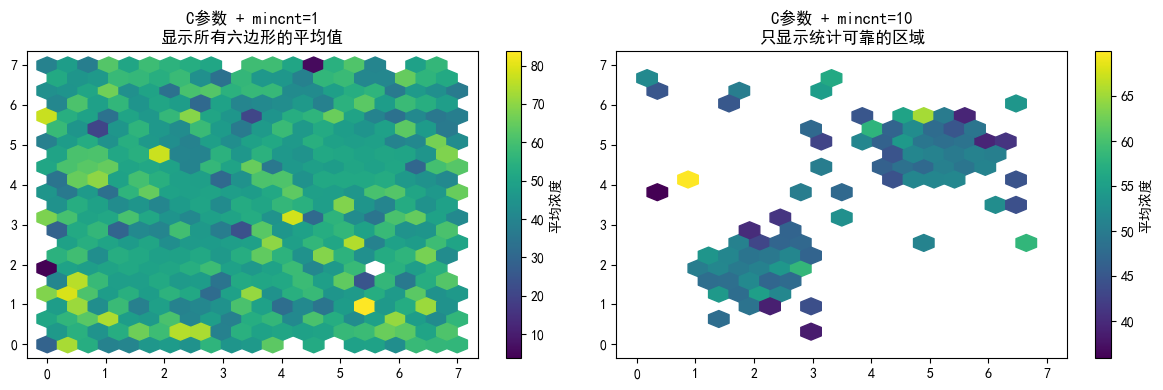

In [6]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False   # 用来正常显示负号

# 生成示例数据：两个密集区域 + 稀疏背景
np.random.seed(42)
n_points = 5000

# 两个密集区域
x_dense1 = np.random.normal(2, 0.3, n_points//4)   # 方差小，数据集中
y_dense1 = np.random.normal(2, 0.3, n_points//4)

x_dense2 = np.random.normal(5, 0.4, n_points//4)
y_dense2 = np.random.normal(5, 0.4, n_points//4)

# 稀疏背景
x_sparse = np.random.uniform(0, 7, n_points//2)   # 方差大，数据分散
y_sparse = np.random.uniform(0, 7, n_points//2)

x = np.concatenate([x_dense1, x_dense2, x_sparse])
y = np.concatenate([y_dense1, y_dense2, y_sparse])

# 使用 C 参数时的 mincnt 效果
C = np.random.normal(50, 20, len(x)) 

plt.figure(figsize=(12, 4))

# 无 mincnt 限制
plt.subplot(121)
hex1 = plt.hexbin(x, y, C=C, gridsize=20, mincnt=1)
plt.title('C参数 + mincnt=1\n显示所有六边形的平均值')
plt.colorbar(hex1,label='平均浓度')

# 有 mincnt 限制
plt.subplot(122)
hex2 = plt.hexbin(x, y, C=C, gridsize=20, mincnt=10)
plt.title('C参数 + mincnt=10\n只显示统计可靠的区域')
plt.colorbar(hex2, label='平均浓度')

plt.tight_layout()
plt.show()

- 代码说明：
    - 代码中mincnt参数设置为0会出现警告，我们在代码中设置mincnt=1。
    - 右边的图表是使用数据点与mincnt比较，并过滤数据点小于mincnt的六边形绘制。

- marginals参数使用：
    - marginals参数是bool类型，用于设置是否在hexbin图旁边显示x和y方向的边缘分布。绘制的位置在x，y轴边上（x方向下边，y方向左边），默认值是False。这样可以从数据分析有如下好处，并创建更完整的数据可视化：
        - 同时观察二维分布和一维边缘分布
        - 分析每个变量的单独分布特性

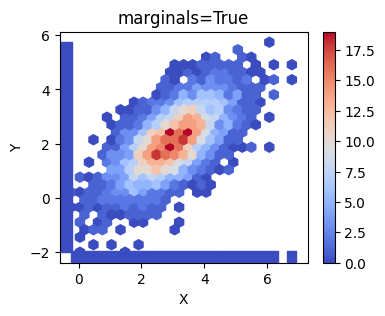

In [4]:
from matplotlib.gridspec import GridSpec

# 创建相关数据
np.random.seed(42)
x = np.random.normal(3, 1, 5000)
y = 0.7 * x + np.random.normal(0, 0.8, 5000)  # 正相关

# 更简单的使用方式 - 让 matplotlib 自动处理布局
plt.figure(figsize=(4, 3))

# 只需要设置 marginals=True
hex = plt.hexbin(x, y, gridsize=25, bins=20, marginals=True, cmap='coolwarm', mincnt=1)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('marginals=True')
plt.colorbar(hex)

plt.show()

- 代码说明：
    - 当设置marginals=True的时候，绘制的边缘分布图表实际是直方图分布。
    - 通过返回的PolyCollection对象的hbar与vbar属性，可以访问两个直方图图表，直方分布图也是PolyCollections对象。

-------